# FX Pairs: Features Built From Fitted Models

**Chapter 9: Time Series Analysis**

Chapter 8's features are arithmetic on past prices: a moving average, a return over
twenty sessions, a ratio of two of them. This notebook builds a different kind. Each
feature here is the output of a model whose parameters were themselves estimated from
price history, so the window those parameters came from is part of what the feature
knows. Three models are fitted, one per section: a state-space model that splits a
spot rate into a slowly-changing level and the quoting noise around it, a two-state
model of when the dollar is calm and when it is turbulent, and a short-memory return
model whose forecast error becomes a surprise measure.

**Learning Objectives**:
- Split a currency pair's price into a slowly-moving level and the noise around it,
  by fitting a model that treats the level as hidden and each observed price as a
  noisy reading of it, from sessions strictly earlier than the ones it speaks for.
- Estimate, for each session, how likely the dollar is to be in its turbulent state,
  from a two-state model that is allowed to read only the sessions up to that day.
- Turn a one-step-ahead return forecast into a feature by keeping what the forecast
  missed, so the feature measures surprise rather than direction.
- Refresh each model's parameters on a declared schedule instead of once per
  cross-validation fold, so that no session's value carries parameters estimated
  from its own future.
- Show that a feature carries no look-ahead by re-running the same recursion on a
  series with its tail deleted and checking that the earlier values do not move.

**Book Reference**: Chapter 9, Sections 9.2 (Kalman), 9.5 (HMM), 9.3 (ARIMA)

**Prerequisites**: FX 4H price bars, which section 1 aggregates to sessions, and
[`02_labels`](02_labels.ipynb), which writes the label parquet read in section 3 and
whose date index the folds are derived from.

**Output Contract**:
- `features/model_based.parquet` -- ten columns, five from the state-space fit, two
  from the dollar-regime fit and three from the return model
- Keys: `timestamp`, `symbol`. There is no `fold` column. A value is bounded by the
  refit schedule `setup.yaml` declares, not by a cross-validation window, so one row
  per pair and session serves every fold and every configured label
- Every value reads observations up to and including its own session, and carries
  parameters estimated from sessions strictly earlier than it
- The burn-in prefix each model spends before its first estimate carries no value

In [1]:
"""FX Pairs: Features Built From Fitted Models."""

import logging
import multiprocessing
import os
import re
import warnings
from concurrent.futures import ProcessPoolExecutor

import numpy as np
import pandas as pd
import plotly.graph_objects as go
import polars as pl
from hmmlearn.hmm import GaussianHMM
from IPython.display import display
from ml4t.diagnostic.evaluation.stats import benjamini_hochberg_fdr
from ml4t.diagnostic.metrics import compute_ic_hac_stats, cross_sectional_ic_series
from ml4t.diagnostic.splitters.calendar import TradingCalendar
from plotly.subplots import make_subplots
from scipy.optimize import minimize
from statsmodels.tsa.arima.model import ARIMA
from threadpoolctl import threadpool_limits

from case_studies.utils.artifact_digest import value_digest
from case_studies.utils.temporal import (
    arima_one_step_forecast,
    filtered_state_probs,
    refit_boundaries,
    sort_states_by_variance,
    walk_forward_feature,
    write_model_based,
)
from data import load_fx_pairs
from utils.artifact_specs import load_setup_config, resolve_label_buffer
from utils.cv_splits import generate_cv_splits, load_evaluation_config
from utils.paths import get_case_study_dir
from utils.style import COLORS, show_plotly_with_alt

warnings.filterwarnings("ignore")
logging.getLogger("hmmlearn.base").setLevel(logging.ERROR)

The next cell holds what a reader may override to run a smaller version of the notebook
first: how many pairs are fitted and how many of the walk-forward windows the validation
screen at the end covers.

What is *not* here is the estimation schedule. How much history each model spends before
its first fit and how often it is re-estimated are part of what the feature means, not
settings to trade runtime against, so they are read from `setup.yaml` in the cell below
alongside the feature windows. The three `*_OVERRIDE` settings are the reduction levers
for that: each is zero here, meaning "use what `setup.yaml` declares", and a positive
value replaces the declaration for one run. They are named so that nothing reading this
file can mistake a reduction for the definition.

`START_DATE` is the earliest session to load. 2011 is where the OANDA four-hour history
begins, so it is the whole file rather than a choice about how much of it to use.

In [2]:
CASE_STUDY_ID = "fx_pairs"
# 0 means every pair and every fold; a positive value keeps that many of each.
MAX_SYMBOLS = 0
MAX_FOLDS = 0
START_DATE = "2011-01-01"
# 0 keeps every model's declared refit cadence. A positive value replaces all three with
# it, which is how a smoke run bounds the walks without narrowing the universe: fewer
# estimates, the same rows and the same columns. The burn-ins are never overridden - a
# shorter one would move which sessions carry a value, and the coverage assertions below
# are about exactly that.
REFIT_EVERY_OVERRIDE = 0
# 0 keeps the declared search effort for the two models that search. Both bound how hard a
# single estimate looks for its optimum, not what window it reads.
KALMAN_MAXITER_OVERRIDE = 0
N_HMM_RESTARTS_OVERRIDE = 0

The session calendar is read from `setup.yaml` rather than named here. It is the
calendar that implements the 5PM rollover, so it decides which session a four-hour
bar belongs to, and `02_labels` reads the same key. A copy typed here would let this
notebook aggregate onto a different session grid than the labels were built on, and
the resulting join would simply lose rows.

In [3]:
CASE_DIR = get_case_study_dir(CASE_STUDY_ID)
LABELS_DIR = CASE_DIR / "labels"
FEATURES_DIR = CASE_DIR / "features"

# A Spearman IC over fewer pairs than this is a rank correlation over a handful of
# points; dates below the floor are dropped from the series rather than averaged in.
MIN_PAIRS_PER_DATE = 8

SETUP = load_setup_config(CASE_STUDY_ID)
SESSION_CALENDAR = SETUP["decision"]["session_calendar"]

# Two windows this notebook needs are already decided in `setup.yaml`, and both are read
# from it rather than typed, so a configuration change reaches the models rather than
# leaving them measuring against a window the feature stage no longer uses.
#
# `kalman_trend` is the fitted level less a moving average of the price, and it is the
# middle of the three moving-average windows the feature configuration declares: the
# shortest sits inside the filter's own responsiveness, so the difference would be mostly
# filter noise, and the longest is slower than a fold's validation year. Taking the same
# window `03_financial_features` gives `price_to_ma_63d` also means the two columns
# measure price against one reference rather than two.
KALMAN_TREND_WINDOW = int(sorted(SETUP["features"]["windows"]["moving_average"])[1])
# The dollar-regime model is given the shortest close-to-close volatility window the
# configuration declares - about a trading month, long enough for a stable estimate and
# short enough to move when the market does.
USD_VOL_WINDOW = int(min(SETUP["features"]["windows"]["close_to_close_volatility"]))
USD_VOL_COL = f"usd_vol_{USD_VOL_WINDOW}d"

### The Estimation Schedule

Three models are fitted below and each is given two numbers: a **burn-in**, the
observations spent before its first estimate, and a **refit cadence**, how many
observations pass before it is estimated again. Together they are what bounds every
parameter in this notebook, and `setup.yaml` declares them beside the feature windows
because an estimation window is part of a fitted feature's definition in the same way a
lookback is.

They are read here rather than typed, so the comments in `setup.yaml` that say what each
count decides stay next to the value the notebook actually uses.

In [4]:
MODEL_BASED = SETUP["model_based"]

KALMAN_BURNIN = int(MODEL_BASED["kalman"]["burnin"])
KALMAN_REFIT_EVERY = int(MODEL_BASED["kalman"]["refit_every"])
KALMAN_MAXITER = int(MODEL_BASED["kalman"]["maxiter"])

HMM_BURNIN = int(MODEL_BASED["hmm"]["burnin"])
HMM_REFIT_EVERY = int(MODEL_BASED["hmm"]["refit_every"])
HMM_N_STATES = int(MODEL_BASED["hmm"]["n_states"])
N_HMM_RESTARTS = int(MODEL_BASED["hmm"]["n_restarts"])
HMM_STABILITY_REL_TOL = float(MODEL_BASED["hmm"]["stability_rel_tol"])

ARIMA_BURNIN = int(MODEL_BASED["arima"]["burnin"])
ARIMA_REFIT_EVERY = int(MODEL_BASED["arima"]["refit_every"])
ARIMA_ORDER = tuple(int(term) for term in MODEL_BASED["arima"]["order"])

if REFIT_EVERY_OVERRIDE:
    KALMAN_REFIT_EVERY = ARIMA_REFIT_EVERY = HMM_REFIT_EVERY = REFIT_EVERY_OVERRIDE
    print(f"Reduced run: every refit cadence replaced with {REFIT_EVERY_OVERRIDE}")
if KALMAN_MAXITER_OVERRIDE:
    KALMAN_MAXITER = KALMAN_MAXITER_OVERRIDE
if N_HMM_RESTARTS_OVERRIDE:
    N_HMM_RESTARTS = N_HMM_RESTARTS_OVERRIDE

print("Estimation schedule, in sessions of each model's own series:")
print(f"  state-space  burn-in {KALMAN_BURNIN:>4}, refit every {KALMAN_REFIT_EVERY:>3}")
print(f"  dollar regime burn-in {HMM_BURNIN:>3}, refit every {HMM_REFIT_EVERY:>3}")
print(f"  return model  burn-in {ARIMA_BURNIN:>3}, refit every {ARIMA_REFIT_EVERY:>3}")

Estimation schedule, in sessions of each model's own series:
  state-space  burn-in  252, refit every  63
  dollar regime burn-in 504, refit every  63
  return model  burn-in 252, refit every  21


## 1. Load the Price History and the Universe

The price file holds four-hour bars. Every model here works on sessions, so the bars are
first collapsed onto the session calendar named in `setup.yaml` - the one that implements
the 5PM rollover, and the same one `02_labels` used, so the two agree on which session a
bar belongs to.

In [5]:
fx_4h = load_fx_pairs(
    frequency="4h",
    start_date=START_DATE,
).select(["symbol", "timestamp", "open", "high", "low", "close", "volume"])

cal = TradingCalendar(SESSION_CALENDAR)
sessions = cal.get_sessions(pd.DatetimeIndex(fx_4h["timestamp"].to_pandas()))
# Retain the original 4H timestamp as `bar_ts` so OHLC sort_by inside agg
# is order-safe (polars group_by does not contractually preserve row order).
fx_4h = (
    fx_4h.rename({"timestamp": "bar_ts"})
    .with_columns(pl.Series("timestamp", sessions.values).cast(pl.Date))
    .drop_nulls("timestamp")
)
prices = (
    fx_4h.group_by(["symbol", "timestamp"])
    .agg(
        pl.col("open").sort_by("bar_ts").first().alias("open"),
        pl.col("high").max().alias("high"),
        pl.col("low").min().alias("low"),
        pl.col("close").sort_by("bar_ts").last().alias("close"),
        pl.col("volume").sum().alias("volume"),
    )
    .sort(["symbol", "timestamp"])
)

### Select the Universe

The universe is the one declared in `setup.yaml`. The labels were built for that
list, so a pair present in the price file but absent from the declared universe
would enter the USD factor and the cross-sectional IC here while appearing in no
downstream join.

In [6]:
SYMBOLS = sorted(SETUP["universe"]["symbols"])
assert len(SYMBOLS) == SETUP["universe"]["n_assets"], (
    f"setup.yaml declares {SETUP['universe']['n_assets']} assets, "
    f"universe.symbols lists {len(SYMBOLS)}"
)
_loaded = set(prices["symbol"].unique().to_list())
assert set(SYMBOLS) <= _loaded, f"price file is missing {sorted(set(SYMBOLS) - _loaded)}"
prices = prices.filter(pl.col("symbol").is_in(SYMBOLS))
if MAX_SYMBOLS:
    SYMBOLS = SYMBOLS[:MAX_SYMBOLS]
    prices = prices.filter(pl.col("symbol").is_in(SYMBOLS))
n_symbols = len(SYMBOLS)
dates = prices.filter(pl.col("symbol") == SYMBOLS[0])["timestamp"].sort().to_list()

print(f"Loaded: {n_symbols} pairs, {len(dates)} dates")
print(f"Period: {dates[0]} to {dates[-1]}")

Loaded: 20 pairs, 3874 dates
Period: 2011-01-03 to 2025-12-31


### What Is In This Universe

A count of pairs is not enough to read the rest of the notebook, because the three
models treat the pairs differently and the differences run along lines the count hides.

The market divides these quotes into two kinds. A **dollar pair** has the US dollar on
one side of the quote, so its move is largely a move in the dollar itself; the
dollar-regime model in section 5 is built from exactly these and no others. A **cross**
is quoted between two other currencies, and the yen crosses are separated out because
the yen is quoted in hundredths rather than ten-thousandths, which puts its price on a
different numeric scale from every other pair in the file.

The table below carries what the later sections depend on: how many sessions each group
has, so the 252-session minimum training length in section 4 can be checked against it,
and how far a session's return typically travels, which is the quantity the state-space
model has to attribute between a moving level and quoting noise. Scale is why the models
read the logarithm of the price rather than the price: the log return of a yen pair and
of a euro pair are comparable, their price levels are not.

In [7]:
_group = (
    pl.when(pl.col("symbol").str.contains("USD"))
    .then(pl.lit("Dollar pair"))
    .when(pl.col("symbol").str.contains("JPY"))
    .then(pl.lit("Yen cross"))
    .otherwise(pl.lit("Other cross"))
)
universe_table = (
    prices.with_columns(
        _group.alias("group"),
        (pl.col("close") / pl.col("close").shift(1).over("symbol") - 1).alias("_ret"),
    )
    .group_by("group")
    .agg(
        pl.col("symbol").n_unique().alias("pairs"),
        pl.col("symbol").unique().sort().str.join(", ").alias("which"),
        pl.col("timestamp").min().alias("first_session"),
        pl.col("timestamp").n_unique().alias("sessions"),
        (pl.col("_ret").std() * np.sqrt(252) * 100).round(1).alias("annualised_vol_pct"),
    )
    # Two of the three groups hold the same number of pairs, so sorting on the count
    # alone leaves their order to whatever `group_by` happened to emit, which differs
    # between runs. The name breaks the tie, so a reader re-running this sees the table
    # printed here.
    .sort(["pairs", "group"], descending=[True, False])
)
universe_table

group,pairs,which,first_session,sessions,annualised_vol_pct
str,u32,str,date,u32,f64
"""Dollar pair""",7,"""AUD_USD, EUR_USD, GBP_USD, NZD…",2011-01-03,3874,9.2
"""Other cross""",7,"""AUD_NZD, EUR_AUD, EUR_CAD, EUR…",2011-01-03,3874,8.3
"""Yen cross""",6,"""AUD_JPY, CAD_JPY, CHF_JPY, EUR…",2011-01-03,3874,10.9


## 2. Why a Fitted Feature Is Different

A Chapter 8 feature is a function of past prices. A twenty-session return reads twenty
closes and arithmetic turns them into one number. Move the window and the arithmetic is
unchanged; the only thing that decides the value is which prices fall inside it.

A feature here is a function of *parameters that were themselves estimated from prices*.
The state-space model in section 4 does not know how much of a day's move is a lasting
change in the level until it has been told how noisy the quotes are, and it is told that
by fitting two variances to a stretch of history. Only then can it produce a value for a
single session. So the feature at any one date depends on two windows, not one: the
sessions the recursion has walked through, and the window the parameters were fitted on.

That second window is what makes this stage a hazard the last one was not. If the
parameters are fitted on the whole sample, then the value the model reports for a
session in 2016 was shaped by what happened in 2022, and no amount of care in the
recursion removes it. The feature would look ordinary, the notebook would run clean, and
a strategy built on it could not have been run at the time. Nothing in the emitted
numbers reveals this: a leaked fit and an honest one produce columns of the same shape,
the same range and the same plausibility.

The rule that removes it is one sentence: **no parameter behind the value for a session
may have been estimated from that session or a later one.** It has two halves, and the
rest of the notebook is those two halves applied three times:

1. **Refit on a schedule, and let each estimate speak only for what comes after it.**
   A model is fitted on the first `burn-in` observations, that fit produces the values
   for the next `refit_every` observations, and then it is re-estimated on everything up
   to that point. No observation is ever used to fit the model that describes it.
2. **Run the model forward, never backward.** A fitted model can be asked two different
   questions about a past session: what do I believe about it given everything up to it,
   and what do I believe about it given everything including what came after. The second
   is the more accurate answer and it is unusable, because at the time the decision was
   made the later data did not exist. Sections 4, 5 and 6 each take the first, and each
   ends with an executed check that deleting the tail of the series leaves the earlier
   values untouched - which is the only way to tell the two apart from the outside.

**A cross-validation fold does not do the first job, and the arrangement this notebook
used to run is the reason to say so.** Fitting once per fold on the fold's whole training
window and then filtering forward from the *start* of that window closes the leak for the
validation sessions and leaves it open for every training session: the earliest training
rows of a five-year window carry parameters estimated from five years of their own
future, while the validation rows carry parameters estimated only from their past. The
model downstream is then fitted on one version of the column and scored on another.
Nothing raises, because a fold's rows are internally consistent and the artifact records
no estimation window. The schedule replaces the fold as the thing that bounds an
estimate, which is also why the file this notebook writes carries no fold column.

Because these three models read prices and never read a label, the boundary they must
respect is the observation date alone: a fit may use any session it could have seen, and
the holdout is the one stretch it may not. The forward-looking part of the discipline -
not letting a label's outcome window reach into the holdout - binds section 11, where a
label enters for the first time.

## 3. Resolve the Boundaries Before Anything Is Fitted

Two boundaries bind the sections below, and neither is a fold.

The first is **where the holdout opens**. It is the one stretch of history no parameter
here may be estimated from. The recursions still have to produce values across it,
because a holdout evaluation downstream needs the feature on those sessions, so each
walk stops re-estimating at the last session before the boundary and carries that
estimate across the window frozen. A coefficient refitted on holdout sessions is a
parameter estimated on the holdout however careful the recursion around it looks.

The second is **the walk-forward validation windows**. They bound nothing that is fitted
- the schedule does that - but section 10 screens the emitted columns against a forward
return, and a screen run over the sessions a model was fitted on reports how well it fits
history rather than whether it predicts. So the windows are resolved here and the screen
is cut to them.

The windows come from `generate_cv_splits` reading the label file and the sizes in
`setup.yaml`, the same call `05_evaluation` makes. They are laid out by stepping backward
from the date the holdout opens, so **window 0 is the most recent and the
highest-numbered is the oldest**.

In [8]:
all_dates = sorted(prices["timestamp"].unique().to_list())

# The label is the case study's configured primary, not a name typed here: the same
# key picks the label file, the buffer that spaces the windows, and the HAC lag below.
PRIMARY_LABEL = SETUP["labels"]["primary"]
LABEL_BUFFER = resolve_label_buffer(CASE_STUDY_ID, PRIMARY_LABEL, SETUP)
assert LABEL_BUFFER, f"No label buffer configured for {PRIMARY_LABEL}"
# Consecutive daily decisions share (h - 1) days of outcome window, which is what the
# Newey-West lag has to cover. Read from the buffer rather than typed, so a case study
# that moves to a longer label cannot leave a stale lag behind.
LABEL_HORIZON_SESSIONS = int(re.match(r"^(\d+)", LABEL_BUFFER).group(1))
# One holdout boundary, resolved once. It is where every walk stops re-estimating, the
# rule drawn on the schedule figure below, and the bound asserted in section 11.
_EVAL_CONFIG = load_evaluation_config(CASE_STUDY_ID)
HOLDOUT_START = pd.Timestamp(_EVAL_CONFIG["holdout_start"]).date()
HOLDOUT_END = pd.Timestamp(_EVAL_CONFIG["holdout_end"]).date()
print(
    f"Primary label {PRIMARY_LABEL}, buffer {LABEL_BUFFER} -> HAC lag horizon "
    f"{LABEL_HORIZON_SESSIONS}; holdout runs {HOLDOUT_START} to {HOLDOUT_END}"
)

Primary label fwd_ret_1d, buffer 1D -> HAC lag horizon 1; holdout runs 2024-01-01 to 2025-12-31


Each window arrives as four dates. The session counts beside them are how many of this
notebook's own trading sessions fall inside each one.

In [9]:
label_frame = pl.read_parquet(LABELS_DIR / f"{PRIMARY_LABEL}.parquet")
raw_folds = generate_cv_splits(
    label_frame.select("timestamp").unique().sort("timestamp"),
    case_study_id=CASE_STUDY_ID,
    label_buffer=LABEL_BUFFER,
)
folds = []
for split in raw_folds:
    fold = {
        "fold": int(split["fold"]),
        "train_start": pd.Timestamp(split["train_start"]).date(),
        "train_end": pd.Timestamp(split["train_end"]).date(),
        "val_start": pd.Timestamp(split["val_start"]).date(),
        "val_end": pd.Timestamp(split["val_end"]).date(),
    }
    fold["n_train"] = sum(fold["train_start"] <= d <= fold["train_end"] for d in all_dates)
    fold["n_val"] = sum(fold["val_start"] <= d <= fold["val_end"] for d in all_dates)
    folds.append(fold)

if MAX_FOLDS:
    folds = folds[:MAX_FOLDS]

print(f"Resolved {len(folds)} walk-forward windows for the screen in section 10:")
for f in folds:
    print(
        f"  Window {f['fold']}: train {f['train_start']}..{f['train_end']} "
        f"({f['n_train']} sessions), validation {f['val_start']}..{f['val_end']} "
        f"({f['n_val']} sessions)"
    )

Resolved 8 walk-forward windows for the screen in section 10:
  Window 0: train 2011-01-04..2015-12-31 (1289 sessions), validation 2016-01-05..2017-01-03 (258 sessions)
  Window 1: train 2012-01-04..2016-12-30 (1289 sessions), validation 2017-01-04..2018-01-03 (258 sessions)
  Window 2: train 2013-01-03..2018-01-02 (1289 sessions), validation 2018-01-04..2019-01-03 (258 sessions)
  Window 3: train 2014-01-03..2019-01-02 (1289 sessions), validation 2019-01-04..2020-01-03 (258 sessions)
  Window 4: train 2015-01-05..2020-01-02 (1289 sessions), validation 2020-01-06..2021-01-04 (258 sessions)
  Window 5: train 2016-01-05..2020-12-31 (1289 sessions), validation 2021-01-05..2021-12-31 (258 sessions)
  Window 6: train 2017-01-04..2021-12-30 (1289 sessions), validation 2022-01-03..2022-12-30 (258 sessions)
  Window 7: train 2018-01-04..2022-12-29 (1289 sessions), validation 2023-01-03..2023-12-28 (257 sessions)


### One Artifact, Every Label

This case study configures two longer-horizon labels beside the primary one. Under the
arrangement this notebook used to run, that was a hazard needing its own checks: the
artifact carried one fold set cut for the primary label, a model trained on a longer
label resolved *its* boundaries and then read the artifact by `fold` id, and whether
that was safe depended on how the two geometries happened to line up.

It is no longer a question. A value here is bounded by the estimation schedule, which
reads no label at all, so there is one value per pair and session and every label's
model reads it by timestamp. There is nothing for two fold sets to disagree about.

The boundary that does bind is the observation date, and section 11 is where a label
first enters and where the outcome window is checked against the holdout.

### The Estimation Schedule, Drawn

The figure shows what the three walks will do. Each row is one model on its own series.
The grey stretch at the left is its burn-in: observations spent on the first estimate and
carrying no feature value. The blue stretch is where it is refitted on the declared
cadence, each estimate reading everything up to its own start and speaking only for what
follows it. The amber stretch is the holdout, over which the last pre-boundary estimate
is carried frozen.

The bottom row is the eight validation windows, drawn on the same axis. They are there to
be compared against the grey: every one of them opens years after the last burn-in ends,
so no window is screened on a session the schedule left empty.

In [10]:
SCHEDULE_ROWS = [
    ("Return model", ARIMA_BURNIN, ARIMA_REFIT_EVERY, all_dates[1:]),
    ("Dollar regime", HMM_BURNIN, HMM_REFIT_EVERY, None),  # series is built in section 5
    ("State-space", KALMAN_BURNIN, KALMAN_REFIT_EVERY, all_dates),
]

The dollar factor is built in section 5 from a rolling volatility window, so it starts
later than the price panel and its burn-in ends later than the session index alone would
say. The row is drawn from that series rather than from the panel, which means deriving
it here - the same two lines section 5 runs, and the assertion there is what keeps the
two identical.

In [11]:
_usd_legs = [s for s in SYMBOLS if s.startswith("USD_") or s.endswith("_USD")]
_usd_window = int(min(SETUP["features"]["windows"]["close_to_close_volatility"]))
_usd_schedule_dates = (
    prices.filter(pl.col("symbol").is_in(_usd_legs))
    .with_columns((pl.col("close") / pl.col("close").shift(1).over("symbol") - 1).alias("ret"))
    .drop_nulls("ret")
    .group_by("timestamp")
    .agg(pl.col("ret").mean().alias("usd_ret"))
    .sort("timestamp")
    .with_columns(pl.col("usd_ret").rolling_std(_usd_window).alias("_vol"))
    .drop_nulls()["timestamp"]
    .to_list()
)
SCHEDULE_ROWS[1] = ("Dollar regime", HMM_BURNIN, HMM_REFIT_EVERY, _usd_schedule_dates)

In [12]:
fig = go.Figure()
_phase_style = {
    "Burn-in, no value emitted": COLORS["neutral"],
    "Refitted on the declared cadence": COLORS["blue"],
    "Last pre-holdout estimate, carried frozen": COLORS["amber"],
}
_seen: set[str] = set()
schedule_summary = []
for row, burnin, refit_every, series in SCHEDULE_ROWS:
    frozen_at = sum(d < HOLDOUT_START for d in series)
    blocks = refit_boundaries(len(series), burnin, refit_every)
    live = [b for b in blocks if b[0] <= frozen_at]
    schedule_summary.append(
        {
            "model": row,
            "observations": len(series),
            "burnin": burnin,
            "refit_every": refit_every,
            "estimates": len(live),
            "first_value": series[burnin],
            "frozen_from": series[min(frozen_at, len(series) - 1)],
        }
    )
    for phase, (start, end) in (
        ("Burn-in, no value emitted", (series[0], series[burnin])),
        (
            "Refitted on the declared cadence",
            (series[burnin], series[min(frozen_at, len(series) - 1)]),
        ),
        (
            "Last pre-holdout estimate, carried frozen",
            (series[min(frozen_at, len(series) - 1)], series[-1]),
        ),
    ):
        fig.add_trace(
            go.Scatter(
                x=[start.isoformat(), end.isoformat()],
                y=[row, row],
                mode="lines",
                line={"width": 16, "color": _phase_style[phase]},
                name=phase,
                legendgroup=phase,
                showlegend=phase not in _seen,
            )
        )
        _seen.add(phase)

for f in folds:
    fig.add_trace(
        go.Scatter(
            x=[f["val_start"].isoformat(), f["val_end"].isoformat()],
            y=["Validation windows", "Validation windows"],
            mode="lines",
            line={"width": 10, "color": COLORS["copper"]},
            name="Validation window",
            legendgroup="Validation window",
            showlegend="Validation window" not in _seen,
        )
    )
    _seen.add("Validation window")

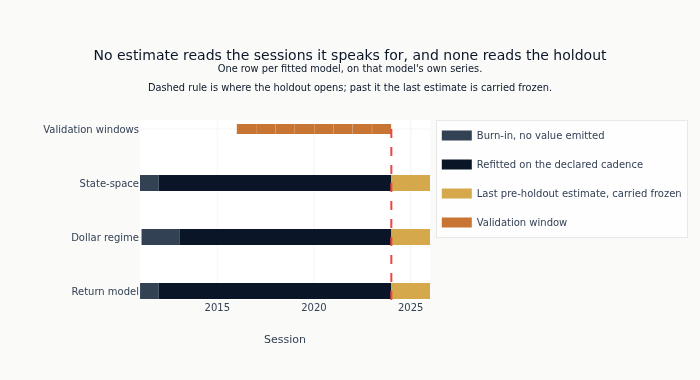

In [13]:
fig.add_vline(x=HOLDOUT_START.isoformat(), line_dash="dash", line_color=COLORS["negative"])
fig.update_layout(
    title=(
        "No estimate reads the sessions it speaks for, and none reads the holdout"
        "<br><sup>One row per fitted model, on that model's own series."
        "<br>Dashed rule is where the holdout opens; past it the last estimate is carried"
        " frozen.</sup>"
    ),
    xaxis_title="Session",
    yaxis_title="",
    height=380,
    margin={"l": 140, "t": 120},
)
show_plotly_with_alt(
    fig,
    "Four horizontal bars against a session axis running from 2011 to the end of 2025. "
    "The top three are the return model, the dollar-regime model and the state-space "
    "model. Each begins with a short grey burn-in stretch at the left, then a long blue "
    "stretch over which it is refitted on its declared cadence, then a short amber "
    "stretch past the dashed vertical rule where the holdout opens and the last estimate "
    "is carried forward frozen. The grey stretches differ in length because the models "
    "spend different burn-ins on series that begin at different dates. The bottom row "
    "holds the eight validation windows as separate short segments stepping up to the "
    "right, all of them well to the right of every grey stretch and all of them ending "
    "before the rule.",
)

The same schedule as numbers. `estimates` is how many separate fits each walk makes
before the holdout freezes it - the count that replaces "one per fold" and the one that
prices the run.

In [14]:
schedule_table = pl.DataFrame(schedule_summary)
schedule_table

model,observations,burnin,refit_every,estimates,first_value,frozen_from
str,i64,i64,i64,i64,date,date
"""Return model""",3873,252,21,148,2011-12-23,2024-01-02
"""Dollar regime""",3853,504,63,45,2013-01-15,2024-01-02
"""State-space""",3874,252,63,50,2011-12-22,2024-01-02


## 4. Where the Price Level Is, and How Fast It Is Moving

The first model treats the price a reader observes as an imperfect reading of something
that cannot be observed directly. There is a true level, it drifts at some rate, and the
quote prints somewhere near it. Two sources of movement are therefore competing to
explain each session: the level genuinely moved, or the quote landed away from a level
that did not. A **local linear trend** model - a state-space model, meaning one written
as a hidden state that evolves plus a noisy observation of it - is the standard way to
separate them.

The hidden state has two components, the level and the slope, and the observation is the
level plus noise:

**State**: $\mathbf{x}_t = [\text{level}_t, \text{slope}_t]^\top$

**Transition**: $\mathbf{x}_t = \mathbf{F}\mathbf{x}_{t-1} + \mathbf{w}_t$

**Observation**: $y_t = [1, 0]\mathbf{x}_t + v_t$

How the split is made is decided entirely by the relative sizes of the two noise terms:
$R$, how far a quote strays from the level, and $Q$, how far the level and its slope
move on their own. Those are the parameters, and they are what gets estimated on each
training window by maximum likelihood - the values under which the training prices are
the most probable thing the model could have produced. Once fitted they are held fixed,
and the recursion runs forward through validation without re-estimating.

The models read the logarithm of the price rather than the price. A yen pair trades near
100 and a euro pair near 1, so a fixed $R$ would mean two different things for the two;
in logarithms both are on the scale of a return, and level, slope, forecast error and
uncertainty are comparable across every pair in the universe.

In [15]:
def kalman_local_linear(
    prices_arr: np.ndarray,
    observation_noise: float = 1.0,
    level_noise: float = 0.01,
    slope_noise: float = 0.001,
) -> dict[str, np.ndarray]:
    """Local linear trend Kalman filter.

    Returns dict with level, slope, innovation, uncertainty arrays.
    """
    n = len(prices_arr)
    F = np.array([[1.0, 1.0], [0.0, 1.0]])
    H = np.array([[1.0, 0.0]])
    Q = np.array([[level_noise, 0.0], [0.0, slope_noise]])
    R = np.array([[observation_noise]])

    x = np.array([prices_arr[0], 0.0])
    P = np.eye(2) * 10.0

    levels = np.zeros(n)
    slopes = np.zeros(n)
    innovations = np.zeros(n)
    uncertainties = np.zeros(n)
    log_lik = 0.0

    for t in range(n):
        x_pred = F @ x
        P_pred = F @ P @ F.T + Q

        y = prices_arr[t] - H @ x_pred
        S = H @ P_pred @ H.T + R

        log_lik += -0.5 * (np.log(2 * np.pi * S[0, 0]) + y[0] ** 2 / S[0, 0])

        K = P_pred @ H.T @ np.linalg.inv(S)
        x = x_pred + K @ y
        P = (np.eye(2) - K @ H) @ P_pred

        levels[t] = x[0]
        slopes[t] = x[1]
        innovations[t] = y[0]
        uncertainties[t] = P[0, 0]

    return {
        "level": levels,
        "slope": slopes,
        "innovation": innovations,
        "uncertainty": uncertainties,
        "log_likelihood": log_lik,
    }

### Fit the Two Noise Sizes to the Training Window

The recursion above returns the log-likelihood of the prices it was given under the
noise sizes it was given, so fitting is a search over those three numbers for the
combination that makes the training prices most probable. Each is a variance and must
stay positive, so the search runs over their logarithms and exponentiates on the way in;
that removes the constraint rather than enforcing it.

In [16]:
def neg_log_likelihood(params: np.ndarray, prices_arr: np.ndarray) -> float:
    """Negative log-likelihood for MLE optimization."""
    obs_noise = np.exp(params[0])
    level_noise = np.exp(params[1])
    slope_noise = np.exp(params[2])
    result = kalman_local_linear(prices_arr, obs_noise, level_noise, slope_noise)
    return -result["log_likelihood"]

A search of this kind has to be told where to start, and the starting point decides
which local optimum it reaches. The variance of the training returns is the natural
choice: it is already on the scale the three parameters live on, and it is measured on
the same pair, so a yen pair and a euro pair each begin from their own magnitude rather
than from a shared constant that would suit one and not the other.

In [17]:
def fit_kalman_mle(train_prices: np.ndarray, maxiter: int = 300) -> tuple[float, float, float]:
    """Estimate Kalman noise parameters via MLE on training data."""
    return_variance = max(float(np.var(np.diff(train_prices))), 1e-10)
    x0 = np.log([return_variance * 0.5, return_variance * 0.1, return_variance * 0.01])
    opt = minimize(
        neg_log_likelihood,
        x0,
        args=(train_prices,),
        method="Nelder-Mead",
        options={"maxiter": maxiter},
    )
    return tuple(np.exp(opt.x))

### Walk It Forward, One Pair at a Time

For each pair, one walk over its whole history. The first `KALMAN_BURNIN` sessions pay
for the first estimate and carry no value. From there the three noise sizes are
re-estimated every `KALMAN_REFIT_EVERY` sessions on everything up to that point, and each
estimate produces the values for the sessions between it and the next one. No session is
ever used to fit the model that describes it.

The recursion is run over the whole prefix each time rather than restarted at the block
boundary. A Kalman filter carries its state forward, so restarting it would throw away
everything the model had learned about where the level was; running from the beginning
with the current parameters and keeping only the block's own rows gives the value a
reader would have had at the time, from a model refreshed on schedule.

`walk_forward_feature` in `case_studies/utils/temporal.py` is that loop, shared with the
other case studies that fit a feature. `freeze_after` is the index of the last
pre-holdout session: past it the walk stops re-estimating and keeps applying the last
estimate it made, so the holdout gets values without contributing a parameter.

Five columns come out of it. `kalman_trend` is how far the fitted level sits above or
below a 63-session moving average of the price, `kalman_slope` is the drift rate the
model currently believes in, `kalman_slope_zscore` puts that drift on the scale of the
spread the *estimation* window showed, `kalman_innovation` is the gap between the
observed price and what the model expected before seeing it, and `kalman_smoothness` is
one over the uncertainty the model attaches to its own level estimate.

The slope z-score is the one that needs its reference stated. Under the old arrangement
the mean and spread came from the fold's training window; here they come from the block's
own estimation window, computed inside the fit and carried with the parameters, so they
end where the parameters do.

In [18]:
KALMAN_FEATURES = ["level", "slope", "slope_zscore", "innovation", "smoothness"]


def kalman_fit(train: np.ndarray) -> dict:
    """Estimate the three noise sizes, and the slope scale, on one estimation window."""
    train_prices = train[:, 0]
    params = fit_kalman_mle(train_prices, maxiter=KALMAN_MAXITER)
    filtered = kalman_local_linear(train_prices, *params)
    return {
        "params": params,
        "slope_mean": float(np.mean(filtered["slope"])),
        "slope_std": float(np.std(filtered["slope"])) + 1e-10,
        "n_train": len(train_prices),
    }


def kalman_apply(fitted: dict, prefix: np.ndarray) -> np.ndarray:
    """Filter a prefix under one set of parameters, one row of features per input row."""
    filtered = kalman_local_linear(prefix[:, 0], *fitted["params"])
    return np.column_stack(
        [
            filtered["level"],
            filtered["slope"],
            (filtered["slope"] - fitted["slope_mean"]) / fitted["slope_std"],
            filtered["innovation"],
            1.0 / (filtered["uncertainty"] + 1e-10),
        ]
    )

One process per pair. The walk makes roughly one Nelder-Mead search per quarter of
history against the one per fold it replaces, and each search evaluates the filter over
the whole expanding prefix, so this is the notebook's dominant cost and the twenty pairs
are independent. A fork context is named rather than left to the default: Python 3.14
defaults to `forkserver`, which re-imports the parent module and cannot reach a function
defined in a notebook kernel.

In [19]:
def _kalman_one_symbol(
    payload: tuple[str, np.ndarray, np.ndarray, int],
) -> tuple[str, np.ndarray, list[dict]]:
    """Walk one pair. Returns its feature block and the parameters behind each estimate."""
    symbol, log_prices, sessions, frozen_at = payload
    estimates: list[dict] = []

    def fit(train: np.ndarray) -> dict:
        fitted = kalman_fit(train)
        estimates.append(
            {
                "symbol": symbol,
                "fit_end": int(len(train)),
                "observation_noise": float(fitted["params"][0]),
                "level_noise": float(fitted["params"][1]),
                "slope_noise": float(fitted["params"][2]),
            }
        )
        return fitted

    values = walk_forward_feature(
        log_prices.reshape(-1, 1),
        timestamps=sessions,
        burnin=KALMAN_BURNIN,
        refit_every=KALMAN_REFIT_EVERY,
        fit=fit,
        apply=kalman_apply,
        n_features=len(KALMAN_FEATURES),
        freeze_after=frozen_at,
    )
    return symbol, values, estimates

In [20]:
kalman_payloads = []
kalman_dates: dict[str, list] = {}
for symbol in SYMBOLS:
    sym_data = prices.filter(pl.col("symbol") == symbol).sort("timestamp")
    sym_dates = sym_data["timestamp"].to_list()
    kalman_dates[symbol] = sym_dates
    kalman_payloads.append(
        (
            symbol,
            np.log(sym_data["close"].to_numpy()),
            sym_data["timestamp"].to_numpy(),
            sum(d < HOLDOUT_START for d in sym_dates),
        )
    )

_kalman_workers = max(1, min(len(kalman_payloads), (os.cpu_count() or 2) - 1))
print(f"Filtering {len(kalman_payloads)} pairs across {_kalman_workers} processes", flush=True)
with ProcessPoolExecutor(
    max_workers=_kalman_workers, mp_context=multiprocessing.get_context("fork")
) as pool:
    kalman_walks = list(pool.map(_kalman_one_symbol, kalman_payloads))

Filtering 20 pairs across 20 processes


The moving average `kalman_trend` measures the level against is a fixed-weight backward
window with nothing estimated in it, so it is computed once over each pair's whole
history rather than inside the walk. Taking the same window `03_financial_features` gives
`price_to_ma_63d` means the two columns measure price against one reference.

In [21]:
kalman_frames = []
kalman_params = []
for symbol, values, estimates in kalman_walks:
    sym_dates = kalman_dates[symbol]
    moving_average = (
        pl.Series(np.log(prices.filter(pl.col("symbol") == symbol).sort("timestamp")["close"]))
        .rolling_mean(KALMAN_TREND_WINDOW, min_samples=1)
        .to_numpy()
    )
    kalman_params.extend(estimates)
    kalman_frames.append(
        pl.DataFrame(
            {
                "timestamp": sym_dates,
                "symbol": symbol,
                "kalman_trend": values[:, 0] - moving_average,
                "kalman_slope": values[:, 1],
                "kalman_slope_zscore": values[:, 2],
                "kalman_innovation": values[:, 3],
                "kalman_smoothness": values[:, 4],
            }
        )
    )

kalman_df = (
    pl.concat(kalman_frames)
    .filter(pl.col("kalman_slope").is_not_nan())
    .sort(["symbol", "timestamp"])
)
print(
    f"\nState-space features: {len(kalman_df):,} rows, {n_symbols} pairs, "
    f"{len(kalman_params):,} estimates"
)


State-space features: 72,440 rows, 20 pairs, 1,000 estimates


**The three checks this section rests on, executed.** Each stops the notebook rather than
leaving plausible numbers behind.

*Every value's parameters end before it.* This is the property the section exists for and
the one the old fold-frozen arrangement broke. `refit_boundaries` returns the same
`(fit_end, emit_end)` pairs the walk used, and every emitted index has to fall at or after
the `fit_end` of the block it belongs to. Checking the schedule rather than the values is
what makes this an assertion about the estimation channel rather than about the recursion.

*Burn-in coverage, reported rather than hidden.* Each pair's first `KALMAN_BURNIN`
sessions carry no value, and the cell says which sessions those are and what share of the
oldest window's training rows they cost.

*Forward only.* `kalman_local_linear` is a recursion, so the value it reports for session
`i` must not move when the observations after `i` are deleted. This is the distinction
section 2 named as invisible in the emitted numbers: a backward pass would produce a
column of the same shape and range. The truncation runs on the pre-holdout series, the
same boundary every other cell reads its data through.

In [22]:
for symbol, values, _ in kalman_walks:
    n_obs = len(kalman_dates[symbol])
    covered = np.zeros(n_obs, dtype=bool)
    for fit_end, emit_end in refit_boundaries(n_obs, KALMAN_BURNIN, KALMAN_REFIT_EVERY):
        covered[fit_end:emit_end] = True
    emitted = ~np.isnan(values[:, 0])
    assert not (emitted & ~covered).any(), (
        f"{symbol}: a value was emitted at an index no estimation block speaks for"
    )
    assert not emitted[:KALMAN_BURNIN].any(), (
        f"{symbol}: a value was emitted inside the burn-in, before any estimate existed"
    )

_first_valued = kalman_df["timestamp"].min()
_oldest = min(folds, key=lambda f: f["train_start"])
_burnt = sum(_oldest["train_start"] <= d < _first_valued for d in all_dates)
print(
    f"Every state-space value sits at or after the end of the block that estimated it, "
    f"across {len(SYMBOLS)} pairs."
)
print(
    f"Burn-in: the first value is dated {_first_valued}, so the oldest window "
    f"{_oldest['fold']} loses {_burnt} of its {_oldest['n_train']} training sessions "
    f"({_burnt / _oldest['n_train']:.0%}) and none of its {_oldest['n_val']} validation "
    f"sessions."
)
assert _first_valued < min(f["val_start"] for f in folds), (
    "the burn-in reaches into a validation window, so the screen in section 10 would run "
    "on sessions this feature never valued"
)

Every state-space value sits at or after the end of the block that estimated it, across 20 pairs.
Burn-in: the first value is dated 2011-12-22, so the oldest window 0 loses 251 of its 1289 training sessions (19%) and none of its 258 validation sessions.


In [23]:
seal_prices = np.log(
    prices.filter((pl.col("symbol") == SYMBOLS[0]) & (pl.col("timestamp") < HOLDOUT_START))
    .sort("timestamp")["close"]
    .to_numpy()
)
cut = len(seal_prices) // 2
full_run = kalman_local_linear(seal_prices)
prefix_run = kalman_local_linear(seal_prices[:cut])
kalman_drift = max(
    float(np.abs(full_run[k][:cut] - prefix_run[k]).max()) for k in ("level", "slope", "innovation")
)
assert kalman_drift < 1e-10, f"Kalman state moved by {kalman_drift:.2e} - not a forward filter"
print(
    f"Deleting the last {len(seal_prices) - cut} observations of {SYMBOLS[0]} moves the "
    f"first {cut} filtered states by {kalman_drift:.2e}"
)

Deleting the last 1678 observations of AUD_JPY moves the first 1677 filtered states by 0.00e+00


## 5. When the Dollar Is Calm and When It Is Turbulent

The second model answers a question about the market as a whole rather than about one
pair. Currency volatility arrives in stretches: months where dollar moves are small and
orderly, then a period where they are not, then back. A **hidden Markov model** is the
standard way to describe that. It assumes the market is always in one of a small number
of unobservable states, that each state produces observations with its own mean and
variance, and that the state persists from one session to the next with a fixed
probability. Two states are configured here, and after fitting they are ordered so that
the one with the larger variance is the turbulent one - a naming rule the fit itself does
not supply, since the two states come back in an arbitrary order every time.

What is emitted is not which state the market was in but how likely each session is to
have been in the turbulent one, computed from the sessions up to that day. A probability
carries the model's uncertainty; a hard label discards it.

The larger-variance state is described as turbulent and nothing more. Variance says how
far the dollar travelled, not which way, so it does not identify the state where
investors are retreating from risk - that would need the direction of the move as well,
and this model is not given it.

The model reads one series: an average dollar return across the seven pairs that have
the dollar on one side of the quote. Those seven are the dollar pairs from the universe
table, and the sign has to be fixed before averaging, because `USD_JPY` rising and
`EUR_USD` rising are opposite moves in the dollar. Both sides are derived from the
declared universe rather than listed here, so a universe change cannot silently drop a
leg of the average.

In [24]:
USD_LONG = [s for s in SYMBOLS if s.startswith("USD_")]
USD_SHORT = [s for s in SYMBOLS if s.endswith("_USD")]
print(f"USD factor legs: long {USD_LONG}, short {USD_SHORT}")

daily_rets = prices.with_columns(
    (pl.col("close") / pl.col("close").shift(1).over("symbol") - 1).alias("ret")
).drop_nulls(subset=["ret"])

usd_rets = daily_rets.filter(pl.col("symbol").is_in(USD_LONG + USD_SHORT)).with_columns(
    pl.when(pl.col("symbol").is_in(USD_LONG))
    .then(pl.col("ret"))
    .otherwise(-pl.col("ret"))
    .alias("usd_ret")
)

usd_daily = (
    usd_rets.group_by("timestamp").agg(pl.col("usd_ret").mean().alias("usd_ret")).sort("timestamp")
)

USD factor legs: long ['USD_CAD', 'USD_CHF', 'USD_JPY'], short ['AUD_USD', 'EUR_USD', 'GBP_USD', 'NZD_USD']


The model is given two numbers per session rather than one: the average dollar return
and a rolling standard deviation of it over the window bound above. The return alone
would let the model separate the states only through how far individual sessions
scatter, and the rolling figure states the recent scale directly, which is the quantity
the two states differ in.

In [25]:
usd_daily = usd_daily.with_columns(pl.col("usd_ret").rolling_std(USD_VOL_WINDOW).alias(USD_VOL_COL))

print(f"USD factor series: {len(usd_daily):,} dates")

USD factor series: 3,873 dates


### Reading the Model Forward

The library's own `predict_proba` answers the question section 2 named as unusable: it
returns the probability of each state given the *whole* series, later sessions included.
The probability given only the sessions up to and including the one being scored comes
from the forward recursion, which `case_studies.utils.temporal.filtered_state_probs`
implements. It is imported rather than written out here because six notebooks in this
book need the same recursion, and it reaches one library method that is not part of the
public interface - a detail worth carrying in one place rather than six.

Expectation-maximisation climbs to whichever optimum is nearest its starting point, so
the fit is repeated from several starting points and the highest-likelihood result is
kept. A run whose final step *lowers* the likelihood has not converged, and is discarded
rather than quietly used.

Fixing the starting points is not by itself enough to make this fit reproducible, and
the difference matters because the feature file is identified by a digest of its values.
The initial state means come from a k-means partition of the training sample, and
k-means sums over that sample in parallel. Floating-point addition is not associative,
so the sums depend on how the work happened to be divided across processor threads, and
expectation-maximisation carries that difference forward into the transition matrix and
into every probability the model reports. A seed fixes which starting points are drawn,
not how the arithmetic is scheduled. Holding the fit to a single thread fixes the
schedule too, and it costs seconds here because the series is one column of daily
figures. Measured over three separate runs of this notebook's fit: with the default
thread pool the transition matrix came back different every time; held to one thread it
came back identical every time. The other two models were checked the same way and are
already reproducible across runs.

In [26]:
def fit_best_hmm(X_train: np.ndarray) -> tuple[GaussianHMM, float, int]:
    """Return the highest-likelihood stable training-only HMM fit."""
    best_ll = -np.inf
    best_model = None
    unstable = 0
    for seed in range(N_HMM_RESTARTS):
        try:
            with threadpool_limits(limits=1):
                model = GaussianHMM(
                    n_components=HMM_N_STATES,
                    covariance_type="full",
                    n_iter=100,
                    random_state=seed,
                    tol=1e-4,
                ).fit(X_train)
            history = list(model.monitor_.history)
            final_delta = history[-1] - history[-2] if len(history) >= 2 else 0.0
            # Relative to the likelihood being stepped on: an absolute nat threshold
            # rejects ordinary floating-point chatter at the optimum, which on a
            # likelihood of this magnitude discards every restart.
            scale = max(abs(history[-2]) if len(history) >= 2 else 1.0, 1.0)
            if final_delta < -HMM_STABILITY_REL_TOL * scale:
                unstable += 1
                continue
            score = model.score(X_train)
            if np.isfinite(score) and score > best_ll:
                best_ll, best_model = score, model
        except Exception:
            continue
    if best_model is None:
        raise RuntimeError("No stable HMM fit")
    return best_model, best_ll, unstable

Two columns come out. `hmm_regime_prob_high_vol` is the probability the session was in
the higher-variance state, and `hmm_regime_transition_5d` is how much that probability
has moved over the last five sessions, which turns a level into a measure of a regime
changing.

Only the first is fitted. The five-session difference is arithmetic on the emitted
probability with nothing estimated in it, so it is taken once over the whole column
rather than inside the walk. It is null rather than zero where there is no session five
back to difference against: the panel already carries rows on which the difference is
genuinely zero because the probability did not move, and writing a zero would make the
two indistinguishable.

A difference that straddles a refit is a difference between two parameter vintages. That
is not a defect - it is what a reader watching this feature in production would see on
the day the model was refreshed - but it is worth naming, because it is the one place a
jump in the column can come from something other than the market.

In [27]:
def hmm_fit(train: np.ndarray) -> tuple[GaussianHMM, np.ndarray, float, int]:
    """Estimate the chain on one window, and order its states by fitted variance."""
    model, score, unstable = fit_best_hmm(train)
    return model, sort_states_by_variance(model), score, unstable


def hmm_apply(fitted: tuple, prefix: np.ndarray) -> np.ndarray:
    """P(higher-variance state) at every row of a prefix, by forward recursion."""
    model, order, _, _ = fitted
    return filtered_state_probs(model, prefix)[:, order[1]].reshape(-1, 1)

### Why the Model Reads Percent and Not Decimals

The series handed to the model is multiplied by 100, so a dollar move of a few tenths of
a percent arrives as a number near one rather than as a number near one thousandth. The
reason has nothing to do with the market and everything to do with two constants inside
`GaussianHMM`, each of which adds a fixed amount to a state's variance and neither of
which scales with the data it is given:

- `min_covar` is added to the covariance the fit *starts* from, so it decides where the
  search begins rather than where it ends. It is not a floor on the fitted value.
- `covars_prior` is added at every step of the fit, divided by how many observations the
  state currently holds. It inflates each state's variance estimate by an amount that
  shrinks as the state takes on more observations.

Both defaults are sized for data of order one. A daily FX return is three orders of
magnitude smaller than that and its variance five, which puts the variance below either
constant - so on decimal returns the fit would begin from a covariance that is
essentially the constant rather than the data, and would return variances visibly
inflated by the second. Multiplying by
100 multiplies the variance by 10,000 and puts it in the range those defaults were
chosen for.

The cell below measures both effects against the series they act on rather than
asserting them.

In [28]:
HMM_SCALE = 100.0  # decimal returns -> percent, so the two fixed constants stay small
HMM_MIN_COVAR = GaussianHMM().min_covar  # added to the initial covariance
HMM_COVARS_PRIOR = GaussianHMM().covars_prior  # added at every fitting step

The walk runs over the whole series, holdout sessions included, because the holdout needs
a value on every one of them. What must not reach into the holdout is an *estimate*, and
that is `freeze_after`'s job rather than a cut on the input: past the last pre-holdout
session the walk stops re-estimating and keeps applying what it last fitted.

The variance printed below is measured on the pre-holdout part alone. It is the
measurement the whole scaling argument rests on, and a constant chosen by looking at the
holdout is a parameter estimated on the holdout whatever the code around it does.

In [29]:
full_usd = usd_daily.drop_nulls(subset=["usd_ret", USD_VOL_COL])
usd_dates = full_usd["timestamp"].to_list()
usd_arr = full_usd.select(["usd_ret", USD_VOL_COL]).to_numpy() * HMM_SCALE
HMM_FROZEN_AFTER = sum(d < HOLDOUT_START for d in usd_dates)
_native = (
    full_usd.filter(pl.col("timestamp") < HOLDOUT_START).select(["usd_ret", USD_VOL_COL]).to_numpy()
)
assert len(_native) == HMM_FROZEN_AFTER, (
    "the pre-holdout prefix and the freeze index disagree, so the walk would re-estimate "
    "on a session the scaling measurement excludes"
)
print(
    f"USD series: {len(usd_dates):,} sessions, {usd_dates[0]} to {usd_dates[-1]}; "
    f"parameters frozen after {usd_dates[HMM_FROZEN_AFTER - 1]}, the last before the holdout"
)

USD series: 3,853 sessions, 2011-02-01 to 2025-12-31; parameters frozen after 2023-12-29, the last before the holdout


Both comparisons are against the variance of the return column the model actually reads.
The second constant is divided by the number of observations a state holds, so splitting
the fitted sample evenly between the two states gives its order of magnitude without
refitting anything.

In [30]:
native_var = float(_native[:, 0].var())
scaled_var = float((_native[:, 0] * HMM_SCALE).var())
obs_per_state = len(_native) / HMM_N_STATES
prior_term = HMM_COVARS_PRIOR / obs_per_state

print(f"USD return variance          native {native_var:.3e}   scaled {scaled_var:.3e}")
print(f"Observations per state, approx.    {obs_per_state:,.0f}")
print("\nAt the start, min_covar added straight to the covariance:")
print(
    f"  min_covar {HMM_MIN_COVAR:.1e} / variance   native {HMM_MIN_COVAR / native_var:9.1f}x"
    f"   scaled {HMM_MIN_COVAR / scaled_var:.4f}x"
)
print("\nAt every step, covars_prior spread over a state's observations:")
print(
    f"  prior term {prior_term:.2e}          native inflates "
    f"{1 + prior_term / native_var:.3f}x   scaled inflates {1 + prior_term / scaled_var:.3f}x"
)

USD return variance          native 1.833e-05   scaled 1.833e-01
Observations per state, approx.    1,667

At the start, min_covar added straight to the covariance:
  min_covar 1.0e-03 / variance   native      54.5x   scaled 0.0055x

At every step, covars_prior spread over a state's observations:
  prior term 6.00e-06          native inflates 1.327x   scaled inflates 1.000x


One walk over the whole series, and the loop keeps the restart count it had to discard
along with the transition matrix behind every estimate. There is one market-level series,
so this is one walk rather than one per pair.

In [31]:
hmm_estimates = []
unstable_hmm_fits = 0


def _hmm_recording_fit(train: np.ndarray) -> tuple:
    """Estimate one block and record what came out of it, for the stability panel."""
    global unstable_hmm_fits
    fitted = hmm_fit(train)
    model, order, score, unstable = fitted
    unstable_hmm_fits += unstable
    transition = model.transmat_[np.ix_(order, order)]
    hmm_estimates.append(
        {
            "fit_end": int(len(train)),
            "fit_through": usd_dates[len(train) - 1],
            "persist_low_vol": float(transition[0, 0]),
            "persist_high_vol": float(transition[1, 1]),
            "log_likelihood": float(score),
            "model": model,
            "order": order,
        }
    )
    return fitted


hmm_values = walk_forward_feature(
    usd_arr,
    timestamps=full_usd["timestamp"],
    burnin=HMM_BURNIN,
    refit_every=HMM_REFIT_EVERY,
    fit=_hmm_recording_fit,
    apply=hmm_apply,
    n_features=1,
    freeze_after=HMM_FROZEN_AFTER,
)
print(
    f"Regime chain estimated {len(hmm_estimates)} times; unstable restarts excluded: {unstable_hmm_fits}"
)

Regime chain estimated 45 times; unstable restarts excluded: 0


The matrix below is the **first** estimate the walk made - the one fitted on the burn-in
alone, and therefore on the oldest window in the run. It is named rather than taken from
wherever the loop stopped, because the last estimate is the one carried across the
holdout and describes the most recent history rather than the period the text discusses.

Each row is the state the session starts in and each column the probability of the next
session's state, so the diagonal says how often a state persists. A state that persists
with probability $p$ lasts $1/(1-p)$ sessions on average, which is the last column and is
easier to read than the probability itself.

In [32]:
_first_estimate = hmm_estimates[0]
trans = _first_estimate["model"].transmat_[
    np.ix_(_first_estimate["order"], _first_estimate["order"])
]
transition_table = pl.DataFrame(
    {
        "from_state": ["low_vol", "high_vol"],
        "to_low_vol": [trans[0, 0], trans[1, 0]],
        "to_high_vol": [trans[0, 1], trans[1, 1]],
        "expected_sessions": [1.0 / (1.0 - trans[0, 0]), 1.0 / (1.0 - trans[1, 1])],
    }
)
print(
    f"Transition matrix of the first estimate, fitted through "
    f"{_first_estimate['fit_through']}, states ordered by variance:"
)
transition_table

Transition matrix of the first estimate, fitted through 2013-01-14, states ordered by variance:


from_state,to_low_vol,to_high_vol,expected_sessions
str,f64,f64,f64
"""low_vol""",0.997431,0.002569,389.205047
"""high_vol""",0.008855,0.991145,112.930096


The five-session difference is taken here, over the emitted column, as the section text
said. `shift(5)` leaves the first five valued sessions null because there is nothing five
back to difference against, and the burn-in prefix stays null throughout.

In [33]:
hmm_df = (
    pl.DataFrame(
        {
            "timestamp": usd_dates,
            "hmm_regime_prob_high_vol": hmm_values[:, 0],
        }
    )
    .filter(pl.col("hmm_regime_prob_high_vol").is_not_nan())
    .sort("timestamp")
    .with_columns(
        (pl.col("hmm_regime_prob_high_vol") - pl.col("hmm_regime_prob_high_vol").shift(5)).alias(
            "hmm_regime_transition_5d"
        )
    )
)
print(f"Regime features: {len(hmm_df):,} sessions, {hmm_df['timestamp'].min()} onward")

Regime features: 3,349 sessions, 2013-01-15 onward


**The three checks, against what this section emits.** The schedule check first, then the
burn-in report, then the truncation test. The forward recursion is written out rather
than taken from a library call, so the truncation test is the only thing standing between
it and the probability given the whole series - which would carry every later session
into each earlier value.

In [34]:
_covered = np.zeros(len(usd_dates), dtype=bool)
for fit_end, emit_end in refit_boundaries(len(usd_dates), HMM_BURNIN, HMM_REFIT_EVERY):
    _covered[fit_end:emit_end] = True
_emitted = ~np.isnan(hmm_values[:, 0])
assert not (_emitted & ~_covered).any(), (
    "a regime probability was emitted at an index no estimation block speaks for"
)
assert not _emitted[:HMM_BURNIN].any(), (
    "a regime probability was emitted inside the burn-in, before any estimate existed"
)
assert all(e["fit_through"] < HOLDOUT_START for e in hmm_estimates), (
    "an estimate read a holdout session, so `freeze_after` did not bind"
)
assert hmm_df["timestamp"].max() >= HOLDOUT_START, (
    "the walk emitted nothing inside the holdout, which is the vintage a holdout evaluation reads"
)

_first_regime = hmm_df["timestamp"].min()
_burnt_regime = sum(_oldest["train_start"] <= d < _first_regime for d in usd_dates)
print(
    f"Every regime probability sits at or after the end of the block that estimated it, "
    f"and the last of the {len(hmm_estimates)} estimates reads through "
    f"{hmm_estimates[-1]['fit_through']}, before the holdout opens {HOLDOUT_START}."
)
print(
    f"Burn-in: the first value is dated {_first_regime}, so the oldest window "
    f"{_oldest['fold']} loses {_burnt_regime} of the {sum(_oldest['train_start'] <= d <= _oldest['train_end'] for d in usd_dates)} "
    f"dollar-factor sessions in its training window, and none in its validation window."
)
assert _first_regime < min(f["val_start"] for f in folds), (
    "the regime burn-in reaches into a validation window"
)

Every regime probability sits at or after the end of the block that estimated it, and the last of the 45 estimates reads through 2023-10-09, before the holdout opens 2024-01-01.
Burn-in: the first value is dated 2013-01-15, so the oldest window 0 loses 504 of the 1269 dollar-factor sessions in its training window, and none in its validation window.


In [35]:
seal_obs = usd_arr[:HMM_BURNIN]
seal_model, _, _ = fit_best_hmm(seal_obs)
cut = len(seal_obs) // 2
hmm_drift = float(
    np.abs(
        filtered_state_probs(seal_model, seal_obs)[:cut]
        - filtered_state_probs(seal_model, seal_obs[:cut])
    ).max()
)
assert hmm_drift < 1e-10, f"filtered probabilities moved by {hmm_drift:.2e} - not filtered"
print(
    f"Deleting the last {len(seal_obs) - cut} observations of the burn-in window moves the "
    f"first {cut} probabilities by {hmm_drift:.2e}"
)

Deleting the last 252 observations of the burn-in window moves the first 252 probabilities by 0.00e+00


## 6. What the Return Model Did Not See Coming

The third model is the smallest of the three and its output is the most direct. An
ARIMA(1,0,1) fitted to a pair's daily returns says that today's return is partly
predictable from yesterday's return and partly from yesterday's forecast error - one
autoregressive term and one moving-average term, which is the shortest memory the model
family offers. Daily currency returns are close to unpredictable, so a fit like this
explains very little, and that is the point: the feature kept is not the forecast but
**what the forecast missed**. A large error is a session that moved unlike the recent
past, which is a different quantity from a large return.

Three columns come out: the forecast itself, the error, and that error divided by the
spread of the errors the *estimation window* showed, so a quiet pair and a volatile one
are comparable. That spread moves with the coefficients and is carried alongside them,
so it ends where they do.

The fitted coefficients must not move when the recursion is extended past the window they
were estimated on. `arima_one_step_forecast` is the call that guarantees it: the state
recursion advances with each new observation while the coefficients stay where the fit left
them. It is shared with cme_futures rather than written here, because the same guarantee is
wanted in both and a copy of a guarantee agrees with the original only by luck.

That is still a claim about a library underneath, so the check below goes around the helper
and compares the parameter vectors element by element against `statsmodels` directly. Routing
the check through the helper it is checking would make it agree with itself; an independent
oracle is the point of a seal. It is also why a bare `ARIMA(` survives in the cell below
without violating the one-filter rule - that cell emits no feature value.

In [36]:
def arima_fit(train: np.ndarray) -> dict:
    """Estimate the coefficients on one window, and the spread of its own errors."""
    fitted = ARIMA(train[:, 0], order=ARIMA_ORDER).fit()
    return {"fit": fitted, "resid_std": float(np.std(fitted.resid)) + 1e-10}


def arima_apply(fitted: dict, prefix: np.ndarray) -> np.ndarray:
    """One-step forecasts over a prefix, with the estimation window's error spread."""
    predicted = arima_one_step_forecast(fitted["fit"], prefix[:, 0])
    return np.column_stack([predicted, np.full(len(prefix), fitted["resid_std"])])

One walk per pair, over its whole return series. As with the state-space model the
recursion is run from the beginning of the series each block and only the block's own
rows are kept, because a state-space recursion has no meaningful restart point. The
ARIMA fits are cheap next to the Nelder-Mead searches in section 4, so these run in this
process rather than across a pool.

In [37]:
arima_frames = []
for symbol in SYMBOLS:
    sym_data = prices.filter(pl.col("symbol") == symbol).sort("timestamp")
    sym_dates = sym_data["timestamp"].to_list()
    sym_close = sym_data["close"].to_numpy()
    # A return needs the session before it, so the return series is one shorter than the
    # price series and starts one session later.
    sym_rets = np.diff(sym_close) / sym_close[:-1]
    ret_dates = sym_dates[1:]
    try:
        values = walk_forward_feature(
            sym_rets.reshape(-1, 1),
            timestamps=np.asarray(ret_dates),
            burnin=ARIMA_BURNIN,
            refit_every=ARIMA_REFIT_EVERY,
            fit=arima_fit,
            apply=arima_apply,
            n_features=2,
            freeze_after=sum(d < HOLDOUT_START for d in ret_dates),
        )
    except Exception as exc:
        raise RuntimeError(f"ARIMA walk failed for {symbol}") from exc
    residual = sym_rets - values[:, 0]
    arima_frames.append(
        pl.DataFrame(
            {
                "timestamp": ret_dates,
                "symbol": symbol,
                "arima_forecast": values[:, 0],
                "arima_residual": residual,
                "arima_residual_zscore": residual / values[:, 1],
            }
        )
    )

arima_df = (
    pl.concat(arima_frames)
    .filter(pl.col("arima_forecast").is_not_nan())
    .sort(["symbol", "timestamp"])
)
print(f"\nReturn-model features: {len(arima_df):,} rows across {n_symbols} pairs")


Return-model features: 72,420 rows across 20 pairs


**The same three checks, plus one this section needs on its own.** Schedule, burn-in and
truncation as before. Between them sits the claim particular to this model: that
`apply(..., refit=False)` extends the recursion without re-estimating. Truncation alone
would not catch a re-fit, because a model re-estimated on the longer series is still a
forward pass over it - so the two parameter vectors are also compared element by element.

In [38]:
_arima_ret_dates = (
    prices.filter(pl.col("symbol") == SYMBOLS[0]).sort("timestamp")["timestamp"].to_list()[1:]
)
_covered = np.zeros(len(_arima_ret_dates), dtype=bool)
for fit_end, emit_end in refit_boundaries(len(_arima_ret_dates), ARIMA_BURNIN, ARIMA_REFIT_EVERY):
    _covered[fit_end:emit_end] = True
_valued_dates = set(arima_df.filter(pl.col("symbol") == SYMBOLS[0])["timestamp"].to_list())
assert not any(
    d in _valued_dates
    for d, is_covered in zip(_arima_ret_dates, _covered, strict=True)
    if not is_covered
), f"{SYMBOLS[0]}: a forecast was emitted at a session no estimation block speaks for"

_first_arima = arima_df["timestamp"].min()
_burnt_arima = sum(_oldest["train_start"] <= d < _first_arima for d in all_dates)
print(
    f"Every forecast sits at or after the end of the block that estimated it. Burn-in: the "
    f"first value is dated {_first_arima}, so the oldest window {_oldest['fold']} loses "
    f"{_burnt_arima} of its {_oldest['n_train']} training sessions and none of its "
    f"validation sessions."
)
assert _first_arima < min(f["val_start"] for f in folds), (
    "the return-model burn-in reaches into a validation window"
)

Every forecast sits at or after the end of the block that estimated it. Burn-in: the first value is dated 2011-12-23, so the oldest window 0 loses 252 of its 1289 training sessions and none of its validation sessions.


In [39]:
seal_data = prices.filter(
    (pl.col("symbol") == SYMBOLS[0]) & (pl.col("timestamp") < HOLDOUT_START)
).sort("timestamp")
seal_close = seal_data["close"].to_numpy()
seal_rets = np.diff(seal_close) / seal_close[:-1]
seal_fit = ARIMA(seal_rets[:ARIMA_BURNIN], order=ARIMA_ORDER).fit()
seal_applied = seal_fit.apply(seal_rets, refit=False)
param_drift = float(np.abs(np.asarray(seal_fit.params) - np.asarray(seal_applied.params)).max())
assert param_drift == 0.0, f"apply() re-estimated: parameters moved by {param_drift:.2e}"

seal_cut = len(seal_rets) // 2
full_pred = np.asarray(seal_applied.predict(start=0, end=len(seal_rets) - 1))
prefix_pred = np.asarray(
    seal_fit.apply(seal_rets[:seal_cut], refit=False).predict(start=0, end=seal_cut - 1)
)
arima_drift = float(np.abs(full_pred[:seal_cut] - prefix_pred).max())
assert arima_drift < 1e-10, f"forecasts moved by {arima_drift:.2e} - not a forward pass"
print(
    f"Extending {SYMBOLS[0]} from {ARIMA_BURNIN} to {len(seal_rets)} observations moves the "
    f"fitted parameters by {param_drift:.2e}, and deleting the last "
    f"{len(seal_rets) - seal_cut} of them moves the first {seal_cut} forecasts by "
    f"{arima_drift:.2e}"
)

Extending AUD_JPY from 252 to 3354 observations moves the fitted parameters by 0.00e+00, and deleting the last 1677 of them moves the first 1677 forecasts by 0.00e+00


## 7. Do the Fitted Parameters Move as the Schedule Rolls?

Refitting on a cadence is a decision, and this is where it gets checked. The estimation
windows expand by one quarter at a time for the state-space and regime models and by one
month for the return model, so consecutive estimates overlap almost completely and the
parameters should move slowly. Parameters that come back identical estimate after
estimate say the refitting bought nothing and one fit would have done; parameters that
swing say the feature depending on them means something different in each block, which is
a warning to carry into how it is used.

The left panel is the three noise sizes from the state-space fit, taken as the median
across pairs so one badly behaved pair does not stand for the block. The axis is
logarithmic because the three differ by orders of magnitude by construction: quoting
noise, level movement and slope movement are not comparable quantities.

**Read the observation-noise line before the others.** Where it sits near the level noise
it is making the split the model exists to make. Where it falls instead to a number that
is zero for every practical purpose, the search has run the likelihood off the end of its
own parameter: with $R$ at zero the model believes each observed price exactly, so the
level it reports is the price and the uncertainty it attaches to that level goes to zero.
`kalman_smoothness` is one over that uncertainty, so in those blocks it saturates at the
constant its denominator is floored with. Within a block the column still ranks pairs;
across blocks it is not one scale, which is a property to know before pooling them.

That is a limitation of the fit rather than a break in the estimation discipline. Nothing
about it reaches forward: the search that failed read a prefix ending before the sessions
it then spoke for.

The right panel is how long each of the two dollar states persists. Both self-transition
probabilities sit close enough to one that drawing them directly would put two traces
against the top of the axis with the difference between them invisible, so each is drawn
as the run length it implies, $1/(1-p_{\text{stay}})$ - the quantity a reader would want
anyway, and the one `hmm_regime_transition_5d` responds to.

The return model is refitted per pair and its two coefficients have no market-level
counterpart to plot against a common axis, so it has no line here.

In [40]:
kalman_param_df = pl.DataFrame(kalman_params).with_columns(
    pl.col("fit_end").alias("estimate_through_index")
)
kalman_param_summary = (
    kalman_param_df.group_by("fit_end")
    .agg(
        pl.col("observation_noise").median().alias("observation_noise"),
        pl.col("level_noise").median().alias("level_noise"),
        pl.col("slope_noise").median().alias("slope_noise"),
        pl.len().alias("n_pairs"),
    )
    .sort("fit_end")
    .with_columns(
        pl.col("fit_end")
        .map_elements(lambda i: all_dates[min(int(i), len(all_dates)) - 1], return_dtype=pl.Date)
        .alias("fit_through")
    )
)
hmm_param_df = pl.DataFrame(
    [{k: v for k, v in e.items() if k not in ("model", "order")} for e in hmm_estimates]
).sort("fit_end")

How far the observation noise moves is a scalar, and an axis spanning twenty orders of
magnitude is not where a reader should have to estimate one. A block counts as collapsed
when its median $R$ falls more than six orders below the largest block's - far enough
below ordinary block-to-block movement that the two cannot be confused. The last line
prices what the collapse does to the feature that variance feeds.

In [41]:
_r = kalman_param_summary["observation_noise"]
_zero_threshold = float(_r.max()) * 1e-6
_zeroed = kalman_param_summary.filter(pl.col("observation_noise") < _zero_threshold)
_intact = kalman_param_summary.filter(pl.col("observation_noise") >= _zero_threshold)
print(f"Observation noise R, median across pairs, over {len(kalman_param_summary)} estimates:")
print(
    f"  {len(_intact)} estimates fitting normally: "
    f"{_intact['observation_noise'].min():.2e} to {_intact['observation_noise'].max():.2e}"
)
if len(_zeroed):
    _drop = float(_intact["observation_noise"].min()) / float(_zeroed["observation_noise"].max())
    print(
        f"  {len(_zeroed)} estimates where it went to zero, first "
        f"{_zeroed['fit_through'].min()}: {_zeroed['observation_noise'].min():.2e} to "
        f"{_zeroed['observation_noise'].max():.2e}"
    )
    print(f"  the fall is a factor of {_drop:.1e}, {np.log10(_drop):.1f} orders of magnitude")
print(
    f"Level noise moves by a factor of "
    f"{float(kalman_param_summary['level_noise'].max() / kalman_param_summary['level_noise'].min()):.2f}"
    f" across estimates; slope noise by "
    f"{float(kalman_param_summary['slope_noise'].max() / kalman_param_summary['slope_noise'].min()):.1f}"
)

Observation noise R, median across pairs, over 50 estimates:
  17 estimates fitting normally: 8.25e-09 to 2.84e-07
  33 estimates where it went to zero, first 2011-12-21: 7.27e-18 to 3.65e-16
  the fall is a factor of 2.3e+07, 7.4 orders of magnitude
Level noise moves by a factor of 1.59 across estimates; slope noise by 4310183.1


In [42]:
fig = make_subplots(
    rows=1,
    cols=2,
    subplot_titles=["Fitted noise sizes", "Dollar-state run length"],
    horizontal_spacing=0.12,
)
for column, name, color in (
    ("observation_noise", "Observation noise R", COLORS["blue"]),
    ("level_noise", "Level noise", COLORS["amber"]),
    ("slope_noise", "Slope noise", COLORS["copper"]),
):
    fig.add_trace(
        go.Scatter(
            x=kalman_param_summary["fit_through"].to_list(),
            y=kalman_param_summary[column].to_list(),
            mode="lines",
            name=name,
            line={"color": color},
        ),
        row=1,
        col=1,
    )
# The two panels share one legend, so the regime traces take colours the noise traces do
# not use; a repeated colour in a shared legend reads as a repeated series.
for column, name, color in (
    ("persist_high_vol", "Turbulent state, run length", COLORS["negative"]),
    ("persist_low_vol", "Calm state, run length", COLORS["positive"]),
):
    fig.add_trace(
        go.Scatter(
            x=hmm_param_df["fit_through"].to_list(),
            y=(1.0 / (1.0 - hmm_param_df[column])).to_list(),
            mode="lines",
            name=name,
            line={"color": color, "dash": "dot"},
        ),
        row=1,
        col=2,
    )

The two panels carry different units, so each axis is set on its own. The left one is
labelled in powers of ten rather than in the SI prefixes plotly reaches for by default,
which would render $10^{-6}$ as "1u" - a unit on an axis whose quantity is a variance and
has none.

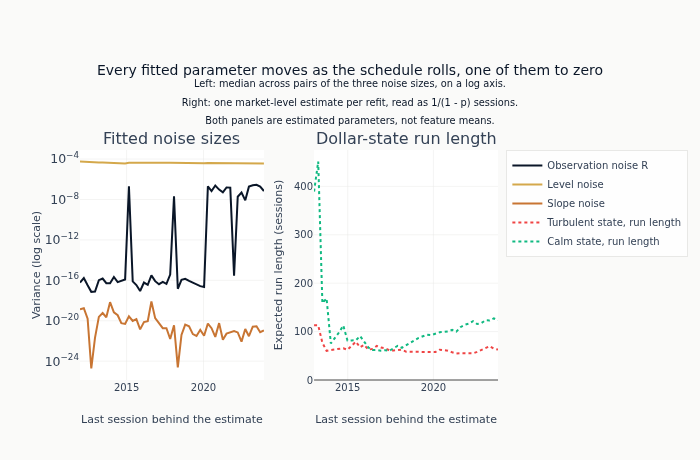

In [43]:
fig.update_yaxes(
    title_text="Variance (log scale)",
    type="log",
    exponentformat="power",
    row=1,
    col=1,
)
fig.update_yaxes(title_text="Expected run length (sessions)", rangemode="tozero", row=1, col=2)
fig.update_xaxes(title_text="Last session behind the estimate", row=1, col=1)
fig.update_xaxes(title_text="Last session behind the estimate", row=1, col=2)
fig.update_layout(
    title=(
        "Every fitted parameter moves as the schedule rolls, one of them to zero"
        "<br><sup>Left: median across pairs of the three noise sizes, on a log axis."
        "<br>Right: one market-level estimate per refit, read as 1/(1 - p) sessions."
        "<br>Both panels are estimated parameters, not feature means.</sup>"
    ),
    height=460,
    margin={"t": 150},
)
show_plotly_with_alt(
    fig,
    "Two panels against the last session behind each estimate, running from 2012 to the "
    "start of the holdout. On the left, the three fitted state-space noise sizes on a "
    "logarithmic axis: the level noise is the largest and holds a nearly flat line, the "
    "slope noise sits many orders below it and also holds, while the observation noise "
    "tracks near the level noise for most estimates and drops away by more than ten orders "
    "of magnitude on the ones where the search puts it at zero. On the right, the expected "
    "run length of each dollar-regime state in sessions, one point per refit, the two "
    "traces moving gradually as their estimation windows expand.",
)

## 8. Bring the Three Sets Together

The three models produce frames of different shapes. The state-space and return models
are fitted per pair, so their rows are keyed by pair and session. The dollar-regime model
reads one market-wide series, so its rows carry no pair at all and the same two values
attach to every pair on a session. Joining it therefore matches many rows to one, and the
two per-pair frames match one to one; each join declares which it expects, so a shape that
changed upstream stops the notebook here rather than multiplying rows quietly.

The key is `(timestamp, symbol)` and there is nothing else in it. Under the arrangement
this notebook used to run there was a third key column, `fold`, recording which fit
produced the row, and the same session carried a different value in each fold. A value is
now bounded by the estimation schedule rather than by a fold, so there is one of them per
pair and session and the fold column has nothing left to record.

In [44]:
temporal_df = kalman_df.sort(["symbol", "timestamp"])

if len(hmm_df) > 0:
    temporal_df = temporal_df.join(hmm_df, on="timestamp", how="left", validate="m:1")

if len(arima_df) > 0:
    temporal_df = temporal_df.join(arima_df, on=["symbol", "timestamp"], how="left", validate="1:1")

temporal_df = temporal_df.sort(["symbol", "timestamp"])

temporal_feature_cols = [c for c in temporal_df.columns if c not in {"timestamp", "symbol"}]
duplicate_keys = temporal_df.select(pl.struct("timestamp", "symbol").is_duplicated().sum()).item()
assert duplicate_keys == 0, f"Duplicate temporal keys: {duplicate_keys}"

print(f"\nMerged features: {len(temporal_df):,} rows, {len(temporal_feature_cols)} columns")
print(f"Features: {temporal_feature_cols}")


Merged features: 72,440 rows, 10 columns
Features: ['kalman_trend', 'kalman_slope', 'kalman_slope_zscore', 'kalman_innovation', 'kalman_smoothness', 'hmm_regime_prob_high_vol', 'hmm_regime_transition_5d', 'arima_forecast', 'arima_residual', 'arima_residual_zscore']


### Where the Joins Left a Gap

The duplicate-key check above catches a join that multiplies rows. A second failure runs
the other way and that check cannot see it: a left join that finds no match writes a null
and conserves the row count exactly, so the keys stay unique while the column stops being
a measurement. The row count is the same either way, which is why this takes its own
check.

Two gaps are expected here and both are the burn-ins. The regime model spends the longest
of the three - 504 sessions of a dollar factor that itself starts after a 21-session
volatility window - so the frame's earliest sessions carry state-space and return values
and no regime value. The return model's own burn-in is shorter than the state-space
model's by one session, because a return needs the session before it. Those rows are
counted and reported rather than dropped: the columns present on them are usable.

What decides whether a gap matters is where it falls. Every one of them sits at the front
of the panel, years before the earliest validation window opens, so every validation row
must carry every value - and that is what the check asserts. A null reaching a validation
row would be a join key that did not match, wearing the shape of a burn-in, and it would
sit inside exactly the rows section 11 measures.

In [45]:
IN_ANY_VALIDATION = pl.any_horizontal(
    [pl.col("timestamp").is_between(f["val_start"], f["val_end"], closed="both") for f in folds]
)
validation_rows = temporal_df.filter(IN_ANY_VALIDATION)
null_census = temporal_df.select(
    [pl.col(c).null_count().alias(c) for c in temporal_feature_cols]
).to_dicts()[0]
val_nulls = validation_rows.select(
    [pl.col(c).null_count().alias(c) for c in temporal_feature_cols]
).to_dicts()[0]

for column, n_null in null_census.items():
    if not n_null:
        continue
    missing = temporal_df.filter(pl.col(column).is_null())
    print(
        f"  {column}: {n_null:,} null of {len(temporal_df):,} "
        f"({n_null / len(temporal_df):.3%}), {missing['timestamp'].n_unique()} sessions, "
        f"{missing['timestamp'].min()} to {missing['timestamp'].max()}"
    )
assert not any(val_nulls.values()), (
    f"a validation row is missing a feature value: { {c: n for c, n in val_nulls.items() if n} }"
)
print(
    f"Columns fully populated: {sum(1 for n in null_census.values() if not n)} "
    f"of {len(temporal_feature_cols)}; "
    f"nulls in the {len(validation_rows):,} validation rows: 0"
)

  hmm_regime_prob_high_vol: 5,460 null of 72,440 (7.537%), 273 sessions, 2011-12-22 to 2013-01-14
  hmm_regime_transition_5d: 5,560 null of 72,440 (7.675%), 278 sessions, 2011-12-22 to 2013-01-21
  arima_forecast: 20 null of 72,440 (0.028%), 1 sessions, 2011-12-22 to 2011-12-22
  arima_residual: 20 null of 72,440 (0.028%), 1 sessions, 2011-12-22 to 2011-12-22
  arima_residual_zscore: 20 null of 72,440 (0.028%), 1 sessions, 2011-12-22 to 2011-12-22
Columns fully populated: 5 of 10; nulls in the 41,260 validation rows: 0


## 9. Write the Artifact

Two properties are checked before the file is written, and both are about the key.

The key is `(timestamp, symbol)` and it has to be unique, so no join downstream can
silently multiply rows. And there must be no `fold` column: a reader that found one would
select rows by a tag rather than by the boundaries of the label it is fitting, which is
the arrangement this notebook was converted away from. The assertion is here rather than
in the prose because a future edit that reintroduced the column would otherwise be
invisible until a downstream join doubled a panel.

In [46]:
assert "fold" not in temporal_df.columns, (
    "the frame carries a fold column: a value here is bounded by the estimation schedule "
    "and not by a cross-validation window, so there is nothing for a fold id to record"
)
assert temporal_df.select(pl.struct("timestamp", "symbol").n_unique()).item() == len(temporal_df), (
    "the artifact is not one row per (timestamp, symbol)"
)
print(
    f"Artifact: {len(temporal_df):,} rows on (timestamp, symbol), "
    f"{temporal_df['symbol'].n_unique()} pairs, {temporal_df['timestamp'].n_unique():,} "
    f"sessions from {temporal_df['timestamp'].min()} to {temporal_df['timestamp'].max()}, "
    f"no fold column."
)

Artifact: 72,440 rows on (timestamp, symbol), 20 pairs, 3,622 sessions from 2011-12-22 to 2025-12-31, no fold column.


The parquet is written together with a short record beside it, in the same form
`03_financial_features` writes beside its own matrix. The record holds a digest -- a short
string computed from the file's contents, such that two files with the same values get
the same string and any change to a value gets a different one. It is computed over the
feature values rather than over the raw file bytes, so re-running the notebook and
producing the same numbers leaves it where it was, while a changed fit moves it.

The record names what the values were built from. That is now the price file alone. Under
the old arrangement it also named the label file, because the label file decided the fold
boundaries and the fold boundaries decided the fits; the schedule reads no label, so
naming one here would record a dependency that no longer exists.

What goes in beside it is the schedule itself, which is the thing a reader needs in order
to know what an emitted value means and the thing the artifact could not previously say.

In [47]:
output_path = FEATURES_DIR / "model_based.parquet"
ARTIFACT_KEY = ["timestamp", "symbol"]
# Derived rather than listed, so a feature added above cannot be left out of the guard that
# checks every declared column carries values.
FEATURE_COLUMNS = [c for c in temporal_df.columns if c not in ARTIFACT_KEY]

FEATURES_DIR.mkdir(parents=True, exist_ok=True)
record = write_model_based(
    temporal_df,
    output_path,
    keys=ARTIFACT_KEY,
    feature_columns=FEATURE_COLUMNS,
    time_column="timestamp",
    fold_column=None,
    written_by="case_studies/fx_pairs/04_model_based_features.py",
    inputs={"load_fx_pairs:4h": value_digest(prices)},
    metadata={
        "estimation_schedule": [
            {
                "model": row["model"],
                "burnin": row["burnin"],
                "refit_every": row["refit_every"],
                "observations": row["observations"],
                "estimates": row["estimates"],
                "first_value": str(row["first_value"]),
                "frozen_from": str(row["frozen_from"]),
            }
            for row in schedule_summary
        ]
    },
)
print(f"Saved: {output_path.relative_to(CASE_DIR)}")
print(f"  Shape: {temporal_df.shape}")
print(f"  Digest: {record['digest']}")

Saved: features/model_based.parquet
  Shape: (72440, 12)
  Digest: 37ff32ecb499d9a4


## 10. Take the Validation Rows, and Look at Them

Everything from here on is about rows no model in this notebook was fitted on. The eight
validation windows are contiguous - window 7's ends the session before window 6's begins
- so restricting to their union gives a continuous run of sessions with no session
counted twice, which the check below asserts rather than assumes.

Training rows are a valid input to a downstream fit; they are not evidence about the
feature, because the estimates behind the later ones read them. The holdout is excluded by
the same cut, since no validation window reaches it.

There is no fold to select on. Under the old arrangement this section had to take each
fold's own rows and stack them, because the same session carried a different value in
every fold and only one of those was out of sample. One value per session is out of sample
for exactly the windows that open after the estimate behind it, which the schedule already
guarantees, so the restriction is a filter on dates.

In [48]:
eval_features = validation_rows.sort(["timestamp", "symbol"])
eval_duplicates = eval_features.select(
    pl.struct("timestamp", "symbol").is_duplicated().sum()
).item()
assert eval_duplicates == 0, f"Overlapping validation features: {eval_duplicates}"
assert eval_features["timestamp"].max() < HOLDOUT_START, (
    "a validation row is dated inside the holdout"
)
print(
    f"Validation rows: {len(eval_features):,} across {eval_features['timestamp'].n_unique():,} "
    f"sessions, {eval_features['timestamp'].min()} to {eval_features['timestamp'].max()}"
)

Validation rows: 41,260 across 2,063 sessions, 2016-01-05 to 2023-12-28


### What the Regime Model Inferred, and What It Read

Before any of this is scored, it is worth seeing one of the fitted quantities against
the series it was inferred from. The figure draws the probability of the turbulent state
on every validation session, with the 21-session dollar volatility the model read on the
axis beneath it. The two should agree in shape without being the same line: the model is
not thresholding volatility, it is asking which of two states makes the pair of numbers
it saw most likely, given where it thought the market was yesterday.

The dotted rules mark where the walk refitted. Each stretch between them was produced by
a separate estimate on everything up to its own start, so a jump exactly at a rule is two
consecutive estimates disagreeing rather than the market changing - which is the one thing
this figure can show and the stability panel in section 7 cannot. There are far more rules
here than there were fold handovers, and that is the change: a handover used to happen
once a year and now happens once a quarter.

Validation sessions the model puts in the turbulent state with probability 0.5 or more: 35.2% of 2,063


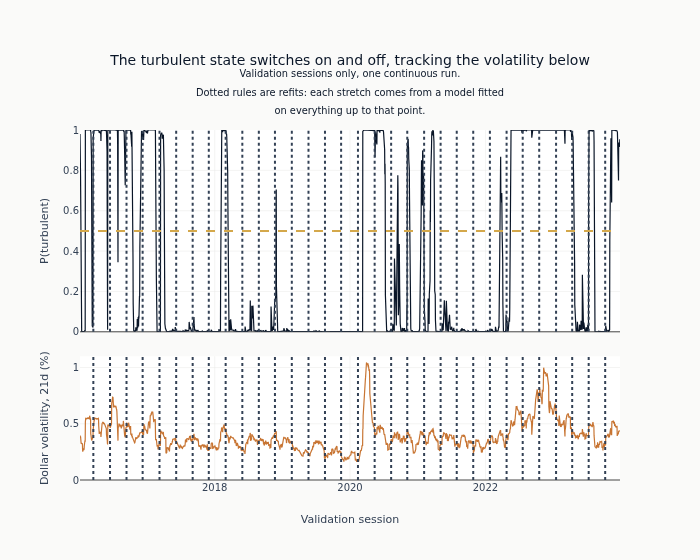

In [49]:
if "hmm_regime_prob_high_vol" in eval_features.columns:
    hmm_validation = (
        eval_features.select("timestamp", "hmm_regime_prob_high_vol")
        .unique("timestamp", keep="last")
        .sort("timestamp")
        .drop_nulls()
        .join(usd_daily.select("timestamp", USD_VOL_COL), on="timestamp", how="left")
    )
    high_vol_share = float((hmm_validation["hmm_regime_prob_high_vol"] >= 0.5).mean())
    print(
        f"Validation sessions the model puts in the turbulent state with probability 0.5 "
        f"or more: {high_vol_share:.1%} of {len(hmm_validation):,}"
    )
    fig = make_subplots(
        rows=2,
        cols=1,
        shared_xaxes=True,
        row_heights=[0.62, 0.38],
        vertical_spacing=0.07,
    )
    fig.add_trace(
        go.Scatter(
            x=hmm_validation["timestamp"],
            y=hmm_validation["hmm_regime_prob_high_vol"],
            mode="lines",
            line={"color": COLORS["blue"], "width": 1.2},
            showlegend=False,
        ),
        row=1,
        col=1,
    )
    fig.add_trace(
        go.Scatter(
            x=hmm_validation["timestamp"],
            y=(hmm_validation[USD_VOL_COL] * 100),
            mode="lines",
            line={"color": COLORS["copper"], "width": 1.2},
            showlegend=False,
        ),
        row=2,
        col=1,
    )
    fig.add_hline(y=0.5, line_dash="dash", line_color=COLORS["amber"], row=1, col=1)
    _shown = (hmm_validation["timestamp"].min(), hmm_validation["timestamp"].max())
    for estimate in hmm_estimates:
        if _shown[0] <= estimate["fit_through"] <= _shown[1]:
            fig.add_vline(
                x=estimate["fit_through"].isoformat(),
                line_dash="dot",
                line_color=COLORS["neutral"],
            )
    fig.update_yaxes(title_text="P(turbulent)", range=[0, 1], row=1, col=1)
    fig.update_yaxes(
        title_text=f"Dollar volatility, {USD_VOL_WINDOW}d (%)",
        rangemode="tozero",
        row=2,
        col=1,
    )
    fig.update_xaxes(title_text="Validation session", row=2, col=1)
    fig.update_layout(
        title=(
            "The turbulent state switches on and off, tracking the volatility below"
            "<br><sup>Validation sessions only, one continuous run."
            "<br>Dotted rules are refits: each stretch comes from a model fitted"
            "<br>on everything up to that point.</sup>"
        ),
        height=560,
        margin={"t": 130},
    )
    show_plotly_with_alt(
        fig,
        "Two stacked panels sharing a time axis of validation sessions. The upper panel "
        "is the probability the model assigns to the turbulent state, which spends most "
        "of its time pinned at zero or one and switches between them abruptly rather "
        "than drifting. The lower panel is the dollar volatility over the same "
        "sessions, and its sustained rises line up with the stretches the upper panel "
        "holds at one. Dotted vertical rules mark where the model was refitted, roughly "
        "one per quarter, and the series runs continuously across them.",
    )
else:
    high_vol_share = float("nan")
    print("Regime figure omitted: the reduced run produces no dollar series.")

## 11. Does Any of This Rank the Cross-Section?

The screen asks one question of each emitted column: on those validation rows, does its
rank correlation with the next session's return, measured across pairs on each session
and then averaged, differ from zero? That statistic - the information coefficient - is
the standard first test of whether a column can order a cross-section, and it is a
diagnostic here rather than a decision: nothing is selected or dropped on it.

`05_evaluation` joins these columns with the Chapter 8 financial set and measures what
they add to it. That comparison needs both feature files and is made there.

In [50]:
label_col = [c for c in label_frame.columns if c not in {"timestamp", "symbol"}][0]
label_endpoints = label_frame.sort(["symbol", "timestamp"]).with_columns(
    pl.col("timestamp").shift(-1).over("symbol").alias("_label_end")
)
eval_df = eval_features.join(label_endpoints, on=["timestamp", "symbol"], how="inner")
assert eval_df["_label_end"].max() < HOLDOUT_START, (
    "A validation decision resolves its label inside the holdout window"
)
print(
    f"Scored: {len(eval_df):,} rows over {eval_df['timestamp'].n_unique():,} sessions "
    f"against {label_col}; the last outcome resolves {eval_df['_label_end'].max()}"
)

Scored: 41,260 rows over 2,063 sessions against fwd_ret_1d; the last outcome resolves 2023-12-29


The join above pairs each validation row with the return the label file records for it,
and the check beside it enforces the one boundary that binds a supervised comparison: a
decision taken on the last validation session has an outcome that resolves a session
later, and that outcome must fall before the holdout opens. This is the constraint
section 2 set aside - the three fits read prices and never a label, so they are bound by
the observation date; the moment a label enters, the date its outcome resolves binds too.

The correlation is measured across pairs on each session, giving one number per session,
and those are then averaged. Consecutive sessions share part of their outcome window, so
the series is serially correlated and its ordinary standard error would be too small; a
Newey-West correction widens it by the amount that overlap implies. That correction reads
row order as time order, so the series must be sorted - `cross_sectional_ic_series` sorts
on the date column, which is why it is used rather than a hand-rolled loop.

Two kinds of missing value come back and both have to go. A session with fewer usable
pairs than the floor returns a **null**: the correlation was not computed. A session on
which the column takes the same value for every pair returns a **NaN**: the correlation
is undefined, since there is nothing to rank. For the two dollar-regime columns, which
are market-wide and therefore identical across pairs, every session is the second kind.

Dropping only the nulls is not a smaller mistake than dropping neither. One NaN reaching
the next cell becomes a NaN average, a NaN p-value, and then a NaN adjusted p-value for
**every** column, because the multiple-testing procedure sorts the whole family together.
The screen would return nothing and report it as nothing found - the same output a
genuine negative result produces.

In [51]:
temporal_ic = {}
for feature in temporal_feature_cols:
    ic_series = (
        cross_sectional_ic_series(
            eval_df.select("timestamp", "symbol", feature),
            eval_df.select("timestamp", "symbol", label_col),
            pred_col=feature,
            ret_col=label_col,
            date_col="timestamp",
            entity_col="symbol",
            method="spearman",
            min_obs=MIN_PAIRS_PER_DATE,
        )
        .drop_nulls("ic")
        .drop_nans("ic")
    )
    if len(ic_series) >= 20:
        temporal_ic[feature] = compute_ic_hac_stats(
            ic_series, ic_col="ic", label_horizon=LABEL_HORIZON_SESSIONS
        )

Ten columns are tested at once, so a p-value read on its own is misleading: test enough
columns against noise and one of them clears any fixed threshold by chance. The
Benjamini-Hochberg procedure
adjusts for how many tests were run, and what it controls is the share of the rejections
that are expected to be false rather than the chance of any false rejection at all -
which is the right trade when the purpose is to decide what is worth carrying forward.

A run over a reduced set of pairs leaves no session above the pair floor and produces an
empty frame, which the branch below handles rather than failing.

In [52]:
feature_names = list(temporal_ic)
if feature_names:
    p_values = [temporal_ic[feature]["p_value"] for feature in feature_names]
    fdr_result = benjamini_hochberg_fdr(p_values, alpha=0.05, return_details=True)
    eval_summary = pl.DataFrame(
        {
            "feature": feature_names,
            "ic_mean": [temporal_ic[f]["mean_ic"] for f in feature_names],
            "hac_se": [temporal_ic[f]["hac_se"] for f in feature_names],
            "naive_tstat": [temporal_ic[f]["naive_t_stat"] for f in feature_names],
            "hac_tstat": [temporal_ic[f]["t_stat"] for f in feature_names],
            "p_value": p_values,
            "adjusted_p": list(fdr_result["adjusted_p_values"]),
            "significant_fdr05": list(fdr_result["rejected"]),
        }
    ).sort(pl.col("ic_mean").abs(), descending=True)
    n_naive_sig = sum(abs(temporal_ic[f]["naive_t_stat"]) > 1.96 for f in feature_names)
    n_hac_sig = sum(p < 0.05 for p in p_values)
    n_fdr_sig = int(fdr_result["n_rejected"])
    print(
        f"Columns with a computable ranking: {len(feature_names)} of {len(temporal_feature_cols)}"
    )
    print(f"  clearing |t| > 1.96 with no overlap correction: {n_naive_sig}")
    print(f"  clearing p < 0.05 once the overlap is corrected for: {n_hac_sig}")
    print(f"  still clearing 0.05 after adjusting for ten tests: {n_fdr_sig}")
else:
    eval_summary = pl.DataFrame(
        schema={
            "feature": pl.String,
            "ic_mean": pl.Float64,
            "hac_se": pl.Float64,
            "naive_tstat": pl.Float64,
            "hac_tstat": pl.Float64,
            "p_value": pl.Float64,
            "adjusted_p": pl.Float64,
            "significant_fdr05": pl.Boolean,
        }
    )
    n_fdr_sig = 0
    print(f"Ranking omitted: no session reaches {MIN_PAIRS_PER_DATE} pairs in this run.")

Columns with a computable ranking: 8 of 10
  clearing |t| > 1.96 with no overlap correction: 0
  clearing p < 0.05 once the overlap is corrected for: 0
  still clearing 0.05 after adjusting for ten tests: 0


The screen in full, one row per column, largest in absolute size first - so a strong
negative correlation sorts above a weaker positive one. Reading across a row:
the average correlation, the corrected standard error behind it, what the uncorrected
and corrected t-statistics would each have said, and what still clears the threshold once
testing ten columns at once is adjusted for. The gap between the two t-statistics is how
much the
overlap between consecutive outcome windows was inflating the evidence.

In [53]:
eval_summary

feature,ic_mean,hac_se,naive_tstat,hac_tstat,p_value,adjusted_p,significant_fdr05
str,f64,f64,f64,f64,f64,f64,bool
"""kalman_slope_zscore""",-0.015015,0.008906,-1.717533,-1.685869,0.091972,0.735779,false
"""kalman_trend""",-0.012674,0.010052,-1.243105,-1.260843,0.207508,0.830033,false
"""arima_forecast""",0.006529,0.006542,0.94965,0.997971,0.31841,0.849094,false
"""kalman_slope""",0.003976,0.008022,0.461506,0.495687,0.620168,0.910451,false
"""arima_residual_zscore""",-0.003311,0.009357,-0.338877,-0.353895,0.723454,0.910451,false
"""arima_residual""",-0.002631,0.009564,-0.264852,-0.275064,0.783295,0.910451,false
"""kalman_innovation""",-0.002471,0.009588,-0.248636,-0.257726,0.796644,0.910451,false
"""kalman_smoothness""",0.000312,0.004778,0.06465,0.065356,0.947897,0.947897,false


### What This Screen Can and Cannot Settle

Two of the ten columns cannot appear in the chart at all. The dollar-regime columns take
the same value for every pair on a session, so there is nothing for a cross-sectional
correlation to rank; that is a property of a market-wide quantity and not a result about
it. Such a column is used by conditioning on it - letting a model treat calm and
turbulent sessions differently - and the test for that is a model, not a correlation.

For the remaining eight, a bar is an estimate and the whiskers are what it is worth. A
column whose interval spans zero has not shown it can rank pairs on this label over this
period. That is a statement about this measurement, not a reason to delete the column:
what a set of features contributes jointly, and what it adds over the Chapter 8 set, is
measured in `05_evaluation`.

Gold is painted only where the largest absolute estimate fails the adjusted threshold,
so the
sentence in the subtitle follows the same branch as the colour and cannot describe a
chart the run did not draw.

In [54]:
if len(eval_summary):
    plot_summary = eval_summary.sort("ic_mean")
    leader = eval_summary["feature"][0]
    bar_colors = [
        COLORS["positive"]
        if row["significant_fdr05"] and row["ic_mean"] > 0
        else COLORS["negative"]
        if row["significant_fdr05"]
        else COLORS["amber"]
        if row["feature"] == leader
        else COLORS["neutral"]
        for row in plot_summary.to_dicts()
    ]
    leader_significant = bool(eval_summary["significant_fdr05"][0])
    leader_note = (
        f"{leader} is the largest in absolute size and clears the adjusted threshold."
        if leader_significant
        else f"Gold marks {leader}, largest in absolute size; it does not clear the threshold."
    )
    ic_title = (
        "Some columns clear the threshold once ten tests are adjusted for"
        if n_fdr_sig
        else "No column clears the threshold once ten tests are adjusted for"
    ) + (
        f"<br><sup>{len(feature_names)} of {len(temporal_feature_cols)} columns can be"
        " ranked across pairs; the two dollar-regime"
        "<br>columns take one value per session and are not rankable."
        "<br>Whiskers are +/-1.96 overlap-corrected standard errors."
        f"<br>{leader_note}</sup>"
    )

The bars carry no printed values: the table above already gives every estimate to three
decimals, and repeating them on the chart competes with the whiskers for the same space.
What the chart adds is the comparison - which columns lean the same way, and how much of
each estimate is spanned by its own uncertainty.

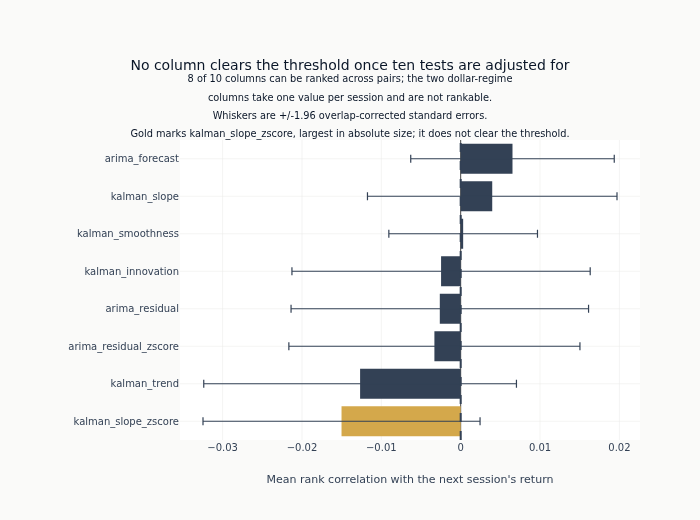

In [55]:
if len(eval_summary):
    fig = go.Figure(
        go.Bar(
            x=plot_summary["ic_mean"],
            y=plot_summary["feature"],
            orientation="h",
            marker_color=bar_colors,
            # Without the interval a bar three times the width of another reads as
            # three times the evidence.
            error_x={
                "type": "data",
                "array": (1.96 * plot_summary["hac_se"]).to_list(),
                "color": COLORS["neutral"],
                "thickness": 1.2,
                "width": 4,
            },
            showlegend=False,
        )
    )
    fig.add_vline(x=0, line_dash="dash", line_color=COLORS["neutral"])
    fig.update_layout(
        title=ic_title,
        xaxis_title="Mean rank correlation with the next session's return",
        yaxis_title="",
        margin={"l": 180, "r": 60, "t": 140},
        height=520,
    )
    show_plotly_with_alt(
        fig,
        "Horizontal bars of the mean rank correlation between each model-derived column "
        "and the next session's return, ordered from the most negative at the bottom to "
        "the most positive at the top, each carrying a whisker of plus and minus 1.96 "
        f"overlap-corrected standard errors. {len(feature_names)} columns are shown. "
        "Every estimate is small against its own whisker, and the whiskers cross the "
        "zero rule the chart draws, so the bars are ordered by size without any of them "
        "standing clear of its own uncertainty.",
    )
else:
    print(f"Chart omitted: no session reaches {MIN_PAIRS_PER_DATE} pairs.")

## Key Takeaways

The method, in the order a reader would apply it to their own data:

1. **Declare the estimation schedule before fitting anything.** How much history a model
   spends before its first estimate, and how often it is refreshed, are part of what the
   feature means. Writing them where the feature windows live keeps a later reader from
   having to reconstruct them from the loop that ran.
2. **Let each estimate speak only for what comes after it.** A cross-validation fold does
   not do this on its own: fitting once per fold and filtering from the start of the
   fold's training window gives every training row parameters drawn from its own future,
   while the validation rows get parameters drawn only from their past. The model is then
   fitted on one version of the column and scored on another, and nothing raises.
3. **Take the forward answer, not the more accurate one.** Every library that fits a
   sequence model will happily report what it believes about a past session given the
   whole series. That answer is the sharper one and it could not have been had at the time.
4. **Check it by truncation.** Delete the tail of the series, re-run, and compare the
   values that remain. Nothing else distinguishes a forward pass from a backward one, and
   the two produce columns of identical shape.
5. **Make the fit reproducible before trusting a digest.** A fixed seed is not enough
   where the numerical work is divided across threads.

**Known limitations**

- Each estimate is held fixed until the next refit, so a break occurring inside a block
  is read by parameters estimated before it. The cadences here are a quarter for the
  state-space and regime models and a month for the return model; a break is at worst
  that far ahead of the estimate that reads it.
- The burn-in prefix carries no value at all. It falls years before the earliest
  validation window, so nothing screened here is affected, but a downstream model whose
  training window opens at the start of the panel fits those sessions on an imputed
  value rather than a measured one. Section 4 prints how many sessions that is.
- Parameters are frozen across the holdout at the last pre-holdout estimate, so the
  holdout is read by a model up to two years stale. That is the price of not estimating
  anything on it, and it is deliberate.
- The dollar-regime model is fitted on one market-wide series, so its two columns take
  the same value for every pair on a session and cannot order a cross-section.
- `kalman_smoothness` inverts the uncertainty the state-space model attaches to its own
  level estimate, and in a linear Gaussian model that quantity follows a recursion in the
  noise parameters and the session index alone - it never reads a price. Within a block the
  column therefore ranks pairs by the noise their own fit estimated, not by anything that
  happened in the sessions being scored.
- The return model's order is fixed at $(1,0,1)$ for every pair and every estimate rather
  than chosen per pair, so its error measures surprise relative to one assumed dynamic.
- Section 11 measures each column on its own. What the set contributes jointly, and what
  it adds over the Chapter 8 features, is `05_evaluation`.

**What the artifact holds, and what the validation screen found in it.**

In [56]:
print(f"Feature columns written:  {len(temporal_feature_cols)}")
print(f"Rows written:             {len(temporal_df):,} on (timestamp, symbol)")
for row in schedule_summary:
    print(
        f"  {row['model']:<14} {row['estimates']:>3} estimates, burn-in "
        f"{row['burnin']}, refit every {row['refit_every']}, first value {row['first_value']}"
    )
if len(eval_summary):
    top_result = eval_summary.row(0, named=True)
    print(f"Columns rankable across pairs:            {len(feature_names)}")
    print(f"Clearing the adjusted 5% threshold:       {n_fdr_sig}")
    print(
        f"Largest in absolute size:                 {top_result['feature']} "
        f"({top_result['ic_mean']:+.4f}, t {top_result['hac_tstat']:+.2f})"
    )
else:
    print(
        f"Ranking omitted: a per-session rank correlation needs {MIN_PAIRS_PER_DATE} "
        "pairs on a session and no session in this run reaches that."
    )

Feature columns written:  10
Rows written:             72,440 on (timestamp, symbol)
  Return model   148 estimates, burn-in 252, refit every 21, first value 2011-12-23
  Dollar regime   45 estimates, burn-in 504, refit every 63, first value 2013-01-15
  State-space     50 estimates, burn-in 252, refit every 63, first value 2011-12-22
Columns rankable across pairs:            8
Clearing the adjusted 5% threshold:       0
Largest in absolute size:                 kalman_slope_zscore (-0.0150, t -1.69)


**Next**: [`05_evaluation.py`](05_evaluation.ipynb) reads this artifact together with
the Chapter 8 financial features and measures what the two sets contribute together.